<a href="https://colab.research.google.com/github/ravikanthd1981/rav4/blob/master/SuperKart_Full_Code_Solution_Ravikanth_Doddapaneni_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
#!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0
# Installing the libraries with the specified versions
# numpy 2.1.3 / pandas 2.2.3 are the closest versions with Python 3.13 support
!pip install numpy==2.1.3 pandas==2.2.3 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 PyGithub==2.6.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.5/351.5 MB 3.6 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# (Hugging Face Hub is not needed - deployment uses GitHub Codespaces)

# **Loading the dataset**

In [8]:
# Uncomment the two lines below when running on Google Colab and the data sits in Google Drive
from google.colab import drive
drive.mount('/content/drive/')

# Read the historical sales data into a DataFrame
kart = pd.read_csv("/content/drive/MyDrive/Colab/SuperKart/SuperKart.csv")

# Work on a copy so the original raw data stays untouched for reference
data = kart.copy()

Mounted at /content/drive/


# **Data Overview**

## View the first and last 5 rows of the dataset

In [9]:
# First 5 rows - a quick look at the structure and sample values
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [10]:
# Last 5 rows - confirms the file was read completely (no trailing junk rows)
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


**Observations**
- Each row is one product in one store, with product attributes (ID, weight, sugar content, display area, type, MRP), store attributes (ID, year, size, city tier, type) and the target `Product_Store_Sales_Total`.
- The data loads cleanly - the first and last rows are well-formed with no header or footer junk.

## Shape of the dataset

In [11]:
# Number of rows (product-store combinations) and columns (attributes)
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


## Data types of the columns

In [12]:
# Column data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Observations**
- The dataset has **8,763 rows and 12 columns**; every row is one product sold in one store.
- 4 columns are floats (`Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Product_Store_Sales_Total`), 1 is an integer (`Store_Establishment_Year`) and 7 are categorical/text (`object`).
- All columns show 8,763 non-null values, so there are no missing values to impute.

## Statistical summary

In [13]:
# Summary statistics for numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [14]:
# Summary for categorical columns: number of levels, most frequent level and its frequency
data.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


**Observations**
- `Product_MRP` ranges from 31 to 266 with mean ≈ 147 and median ≈ 147, i.e. a symmetric price distribution.
- `Product_Weight` ranges from 4 to 22 (mean ≈ 12.65) - also roughly symmetric.
- `Product_Allocated_Area` is small (0.004 – 0.298, median ≈ 0.056) and its mean > median, so it is right-skewed.
- The target `Product_Store_Sales_Total` ranges from 33 to 8,000 with mean ≈ 3,464 and median ≈ 3,452.
- Stores were established between 1987 and 2009.
- `Product_Id` has 8,763 unique values, so each row is a distinct product - it is an identifier and carries no predictive signal by itself.
- There are only **4 stores** (`OUT001`–`OUT004`); `OUT004` is the most frequent (4,676 rows, ≈ 53%).
- `Product_Sugar_Content` has 4 levels, one of which (`reg`) looks like a data-entry variant of `Regular`.

## Duplicate and missing values

In [15]:
# Count fully duplicated rows
print("Duplicate rows:", data.duplicated().sum())

# Count missing values per column
data.isnull().sum()

Duplicate rows: 0


,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


**Observations**
- There are **no duplicate rows** and **no missing values**, so no row removal or imputation is required.

In [16]:
# Levels and their counts for each categorical column (Product_Id excluded as it is an identifier)
for col in data.select_dtypes(include="object").columns.drop("Product_Id"):
    print(data[col].value_counts(), "\n", "-" * 50)

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64 
 --------------------------------------------------
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64 
 --------------------------------------------------
Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64 
 --------------------------------------------------
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64 
 -----------------------

**Observations**
- `Product_Sugar_Content`: Low Sugar (4,885), Regular (2,251), No Sugar (1,519) and **reg (108)** - `reg` will be merged into `Regular` during preprocessing.
- `Store_Size`, `Store_Location_City_Type` and `Store_Type` each map one-to-one onto the four stores, so these columns effectively encode store identity.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [17]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Draws a boxplot (top) and a histogram (bottom) that share the same x-axis.

    data: dataframe
    feature: dataframe column to plot
    figsize: size of figure (default (12,7))
    kde: whether to overlay a density curve (default False)
    bins: number of bins for the histogram (default None -> automatic)
    """
    # Create two stacked subplots with a shared x-axis (boxplot takes 25% of the height)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize=figsize
    )
    # Boxplot with the mean marked as a triangle
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    # Histogram (with the requested number of bins if provided)
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)
    # Dashed green line = mean, solid black line = median
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist2.legend()
    f2.suptitle(f"Distribution of {feature}")
    plt.show()


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Countplot with the count (or percentage) printed on top of each bar.

    data: dataframe
    feature: dataframe column to plot
    perc: show percentages instead of counts (default False)
    n: show only the top n levels (default None -> all levels)
    """
    total = len(data[feature])  # total number of rows, used for percentages
    count = data[feature].nunique()  # number of levels -> drives the figure width
    plt.figure(figsize=((n if n else count) + 2, 5))
    plt.xticks(rotation=90, fontsize=12)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        legend=False,
        palette="Paired",
        order=data[feature].value_counts().index[:n],  # bars sorted by frequency
    )
    # Write the label on top of each bar
    for p in ax.patches:
        label = f"{100 * p.get_height() / total:.1f}%" if perc else int(p.get_height())
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="center", size=11, xytext=(0, 5), textcoords="offset points",
        )
    plt.title(f"Distribution of {feature}")
    plt.show()

### Numerical features

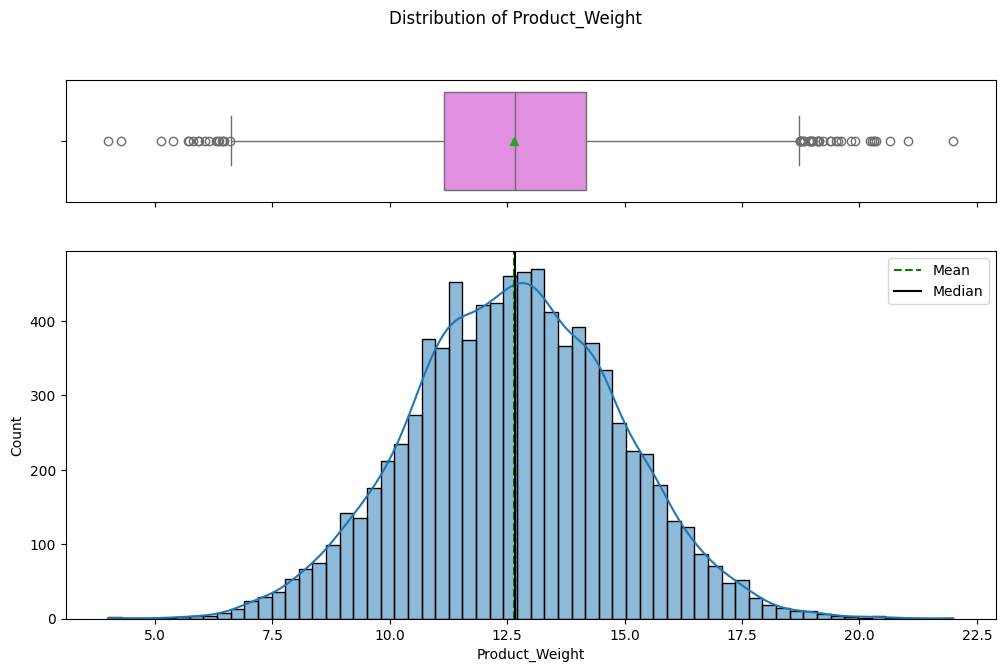

In [18]:
# Product_Weight distribution
histogram_boxplot(data, "Product_Weight", kde=True)

- `Product_Weight` is almost perfectly **normally distributed** around 12.65 (skew ≈ 0.02). A few outliers exist on both sides (≈ 54 by the IQR rule), but the values (4 – 22) are all realistic.

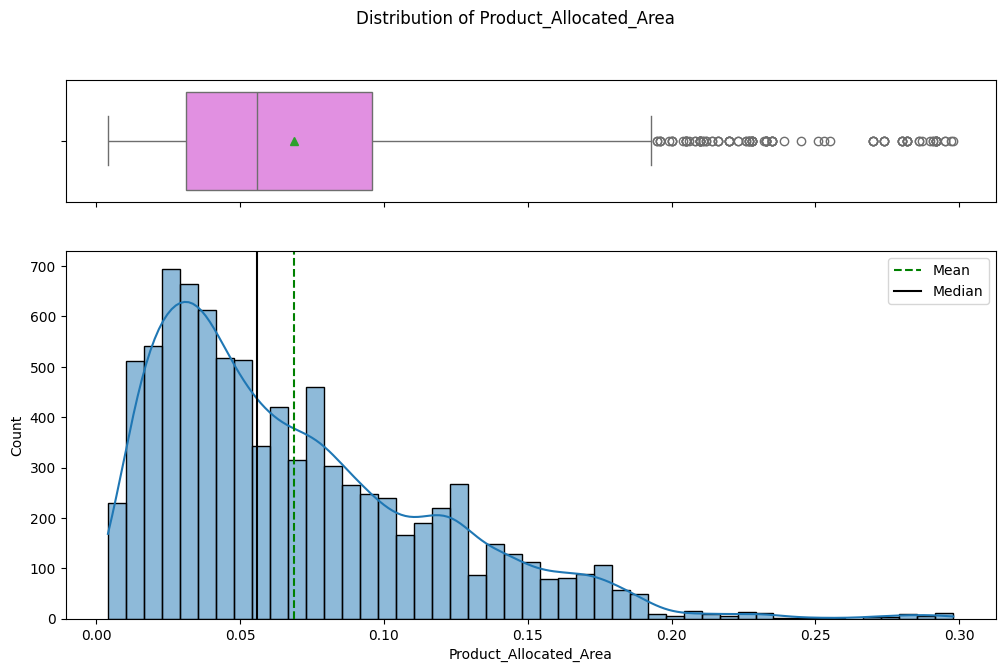

In [19]:
# Product_Allocated_Area distribution
histogram_boxplot(data, "Product_Allocated_Area", kde=True)

- `Product_Allocated_Area` is **right-skewed** (skew ≈ 1.13): most products get less than 10% of the display area, while a small group (≈ 104 outliers) gets up to ~30%. These are genuine merchandising decisions, so they are kept.

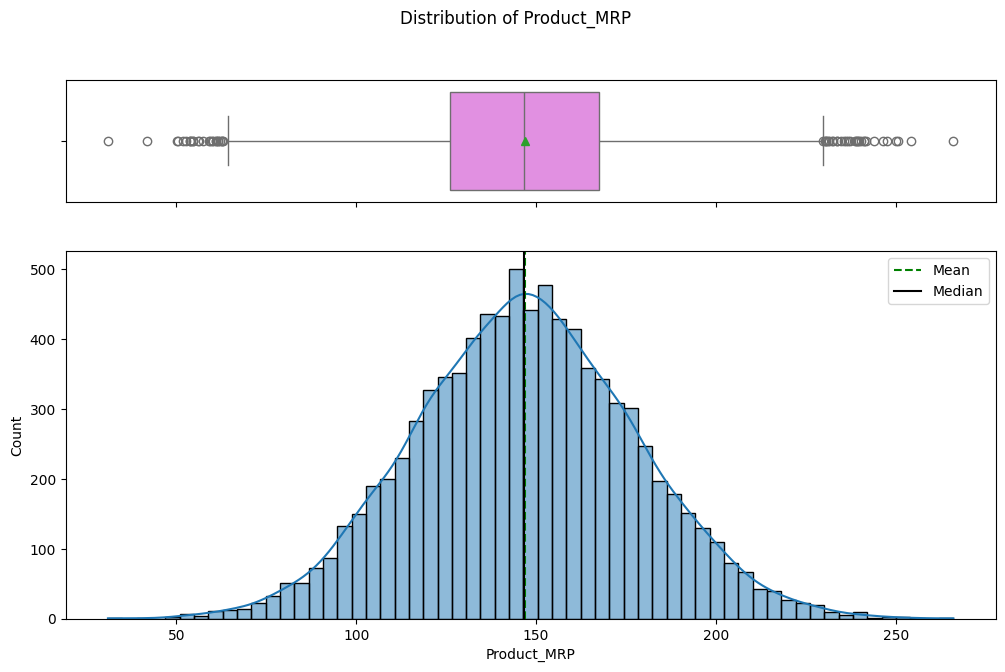

In [20]:
# Product_MRP distribution
histogram_boxplot(data, "Product_MRP", kde=True)

- `Product_MRP` is **normally distributed** around 147 (skew ≈ 0.04); most products are priced between 126 and 168.

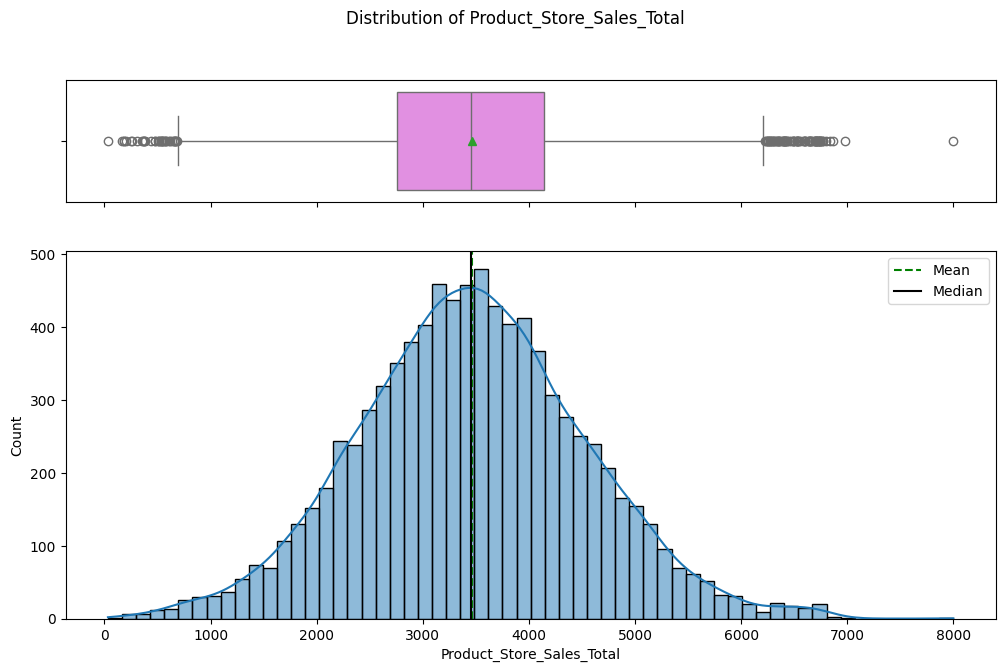

In [21]:
# Target variable distribution
histogram_boxplot(data, "Product_Store_Sales_Total", kde=True)

- The target `Product_Store_Sales_Total` is **close to normal** (mean ≈ 3,464, median ≈ 3,452) with outliers on both tails - very low sales (min 33) come from the small food mart, and the very high values (up to 8,000) from the departmental store. No transformation of the target is needed.

### Categorical features

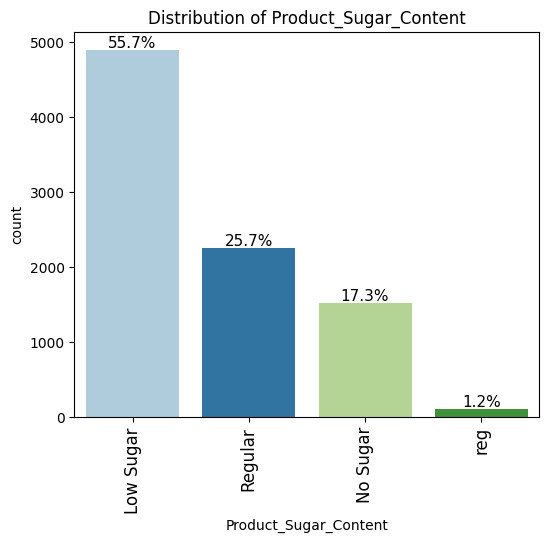

In [22]:
# Share of each sugar-content level
labeled_barplot(data, "Product_Sugar_Content", perc=True)

- **Low Sugar** products dominate (55.7%), followed by Regular (25.7%) and No Sugar (17.3%). `reg` (1.2%) is an inconsistent label for Regular.

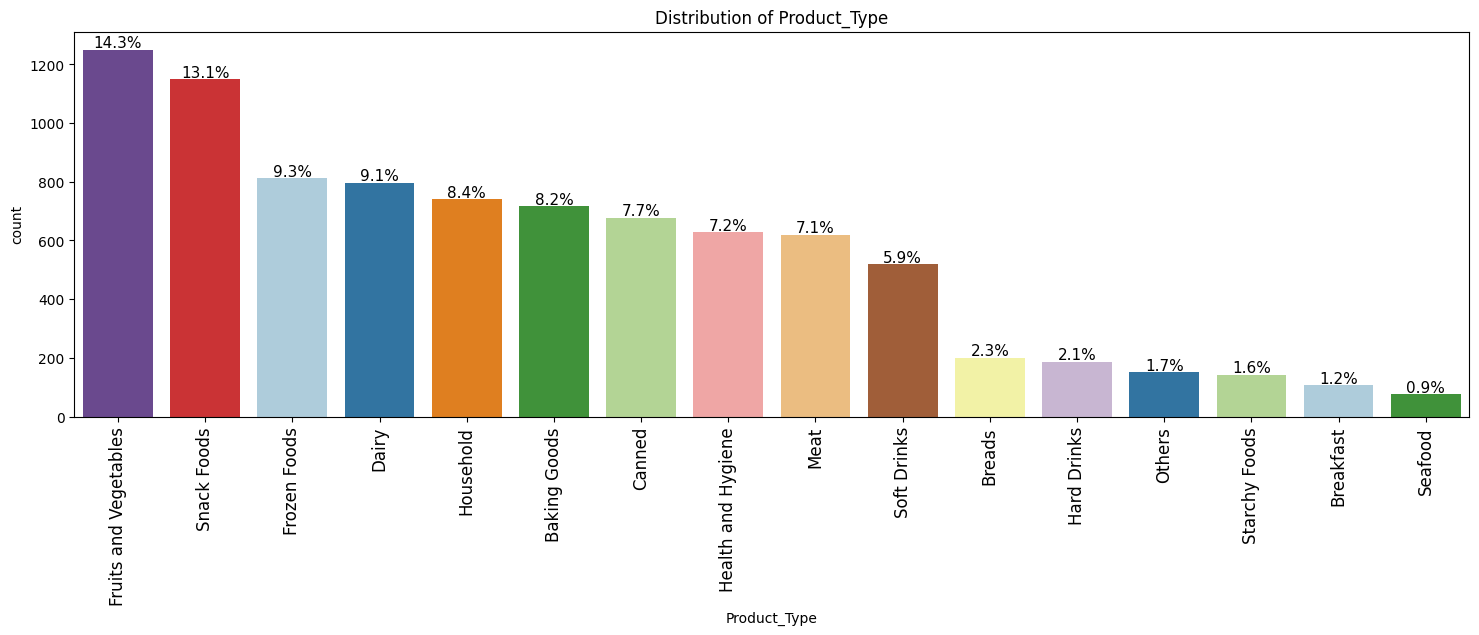

In [23]:
# Share of each product type
labeled_barplot(data, "Product_Type", perc=True)

- **Fruits and Vegetables (14.3%)** and **Snack Foods (13.1%)** are the most common product types, followed by Frozen Foods, Dairy and Household.
- Seafood (0.9%), Breakfast (1.2%), Starchy Foods and Others are the rarest categories.

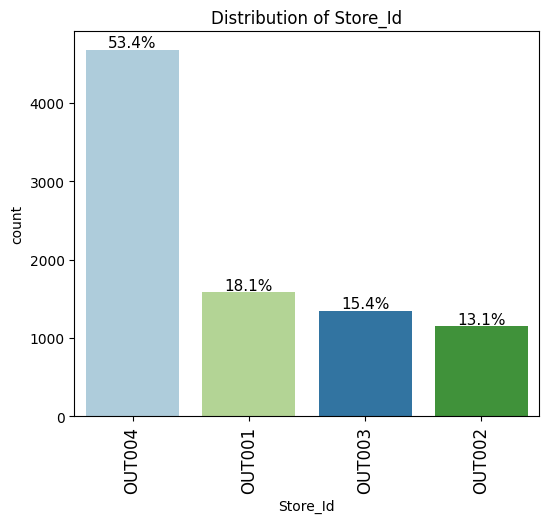

In [24]:
# Share of rows (products) coming from each store
labeled_barplot(data, "Store_Id", perc=True)

- **OUT004 accounts for 53.4%** of all product records; OUT001 (18.1%), OUT003 (15.4%) and OUT002 (13.1%) follow.

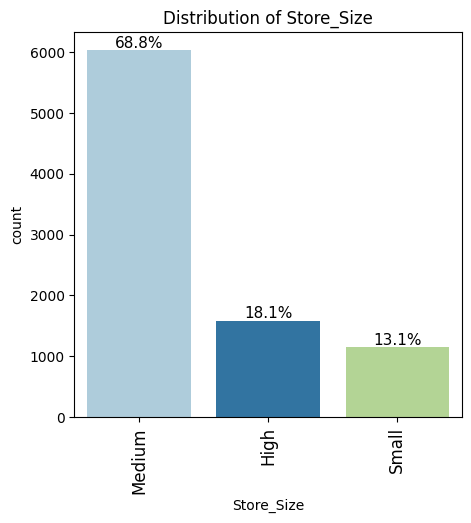

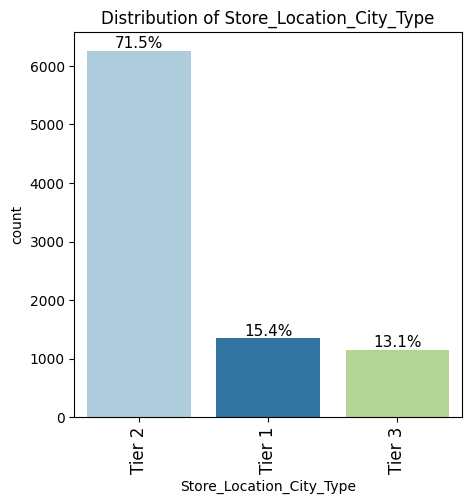

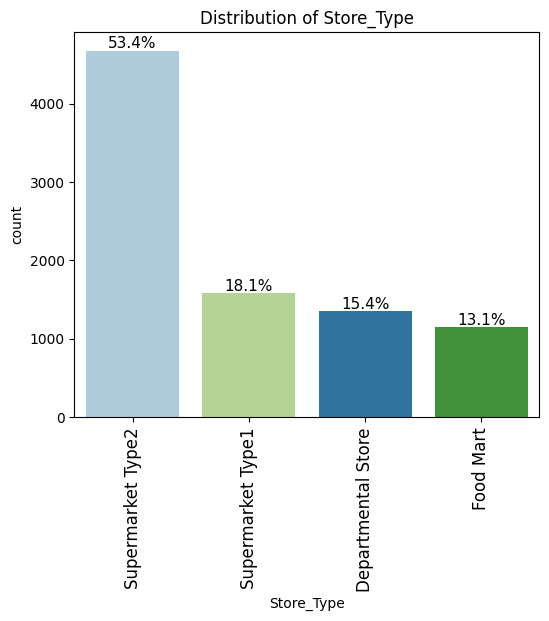

In [25]:
# Store size, city tier and store type
for col in ["Store_Size", "Store_Location_City_Type", "Store_Type"]:
    labeled_barplot(data, col, perc=True)

- **Medium** stores make up 68.8% of the records, High 18.1% and Small 13.1%.
- **Tier 2** cities hold 71.5% of the records (two stores: OUT001 and OUT004), Tier 1 15.4% and Tier 3 13.1%.
- **Supermarket Type2** (OUT004) is the most common store type (53.4%).
- Because each store has a unique combination of size / tier / type, these three columns carry the store-level information into the model once `Store_Id` is dropped.

## Bivariate Analysis

### Correlation between numerical variables

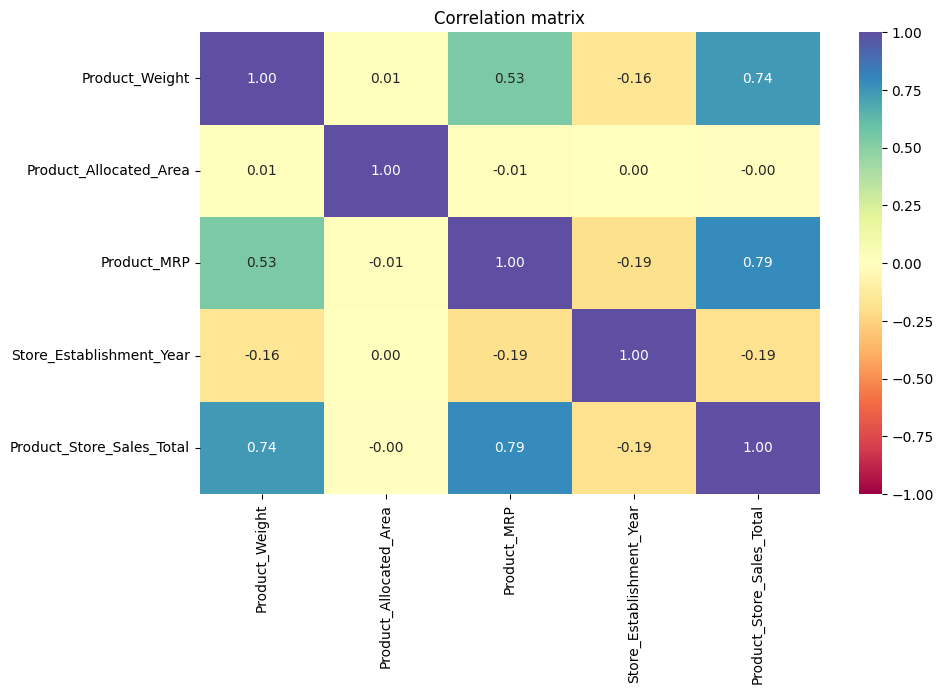

In [26]:
# Correlation heatmap of the numeric columns
num_cols = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(data[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title("Correlation matrix")
plt.show()

- **`Product_MRP` (0.79)** and **`Product_Weight` (0.74)** are strongly and positively correlated with sales - they are the key numeric drivers.
- `Product_MRP` and `Product_Weight` are also correlated with each other (≈ 0.53): heavier products tend to be priced higher.
- `Product_Allocated_Area` has **no linear relationship** with sales (≈ 0.00).
- `Store_Establishment_Year` is weakly negative (-0.19): older stores sell slightly more per product.

### Target vs numerical features

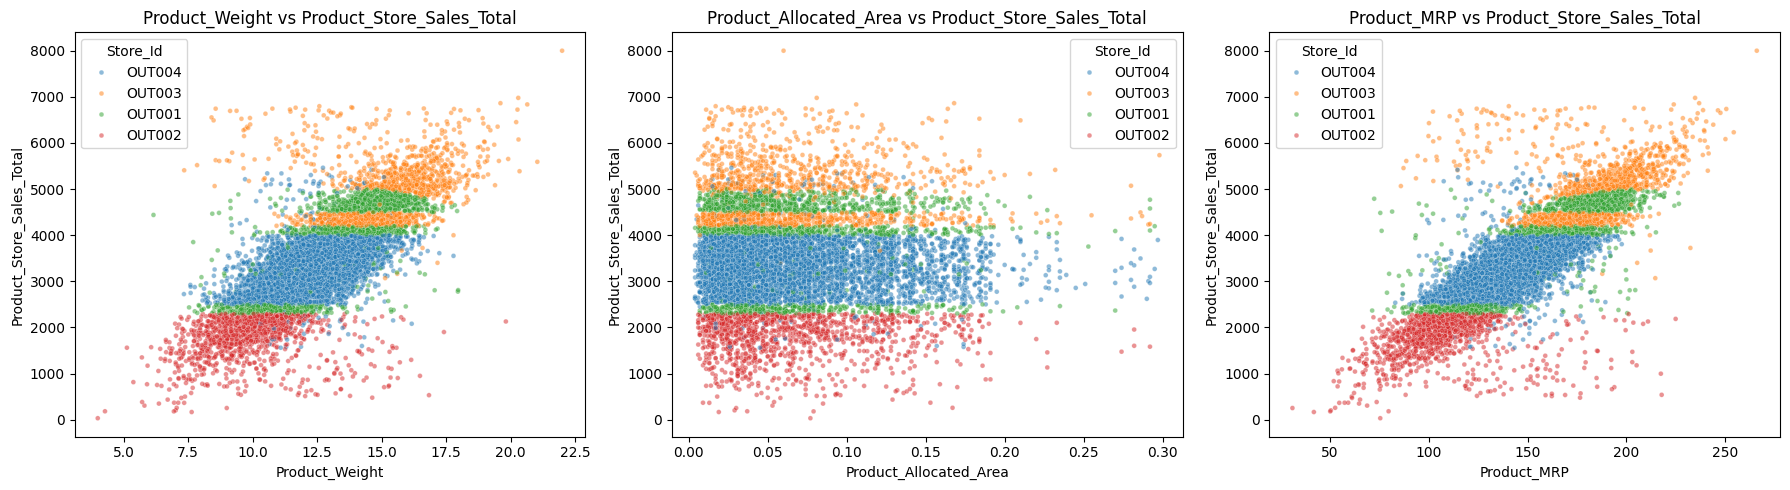

In [27]:
# Scatter plots of each numeric feature against the target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Product_Weight", "Product_Allocated_Area", "Product_MRP"]):
    sns.scatterplot(data=data, x=col, y="Product_Store_Sales_Total", hue="Store_Id", alpha=0.5, s=12, ax=ax)
    ax.set_title(f"{col} vs Product_Store_Sales_Total")
plt.tight_layout()
plt.show()

- Sales rise **linearly with weight and with MRP**, and the points separate clearly into bands by store - store identity shifts the level of sales.
- The allocated-area plot is a flat cloud: giving a product more shelf space does not by itself lead to higher sales in this data.

### Revenue by product attributes

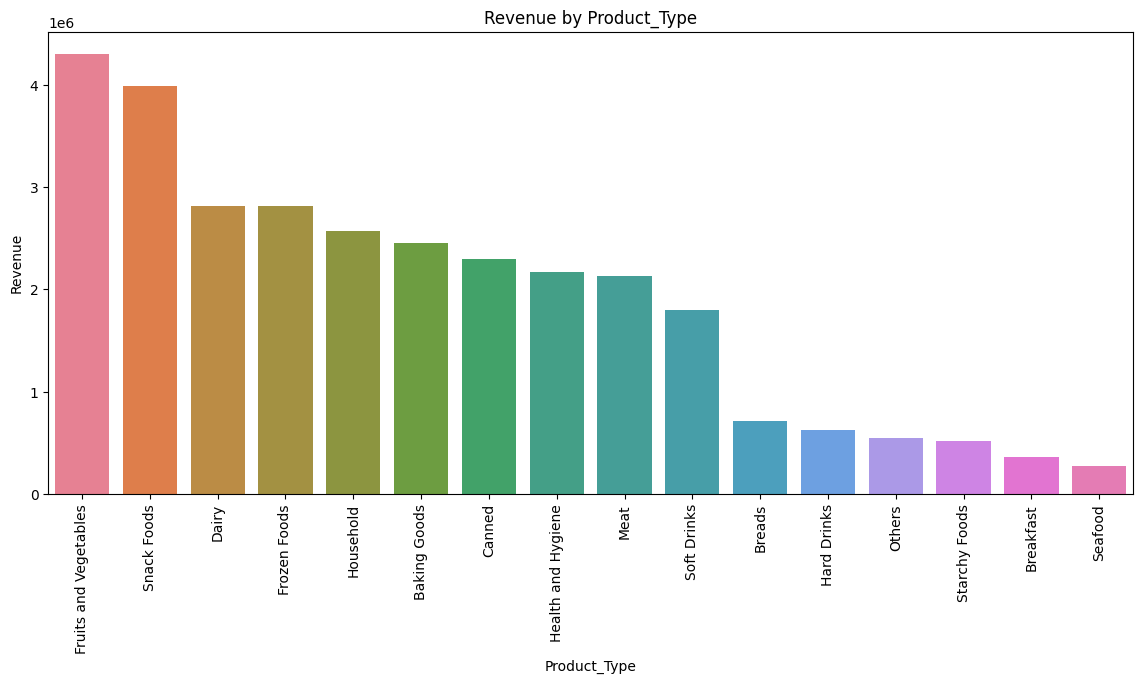

,Product_Store_Sales_Total
Product_Type,
Fruits and Vegetables,14.2
Snack Foods,13.1
Dairy,9.3
Frozen Foods,9.3
Household,8.4
Baking Goods,8.1
Canned,7.6
Health and Hygiene,7.1
Meat,7.0


In [28]:
# Total revenue per product type, sorted from highest to lowest
rev_type = data.groupby("Product_Type")["Product_Store_Sales_Total"].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
sns.barplot(x=rev_type.index, y=rev_type.values, hue=rev_type.index, legend=False)
plt.xticks(rotation=90)
plt.ylabel("Revenue")
plt.title("Revenue by Product_Type")
plt.show()
(rev_type / rev_type.sum() * 100).round(1)

- **Fruits and Vegetables (≈ 4.30 M, 14.2%)** and **Snack Foods (≈ 3.99 M, 13.1%)** generate the most revenue, followed by Dairy and Frozen Foods (≈ 2.81 M each).
- Seafood, Breakfast, Starchy Foods and Others each contribute below 2% of revenue.

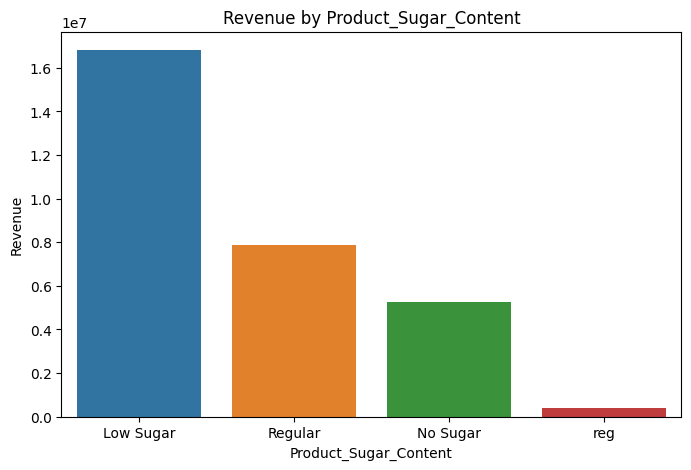

In [29]:
# Total revenue by sugar content
rev_sugar = data.groupby("Product_Sugar_Content")["Product_Store_Sales_Total"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=rev_sugar.index, y=rev_sugar.values, hue=rev_sugar.index, legend=False)
plt.ylabel("Revenue")
plt.title("Revenue by Product_Sugar_Content")
plt.show()

- Low Sugar products bring in ≈ 16.8 M (55%) of revenue, which follows their share of the product mix.

### Revenue by store attributes

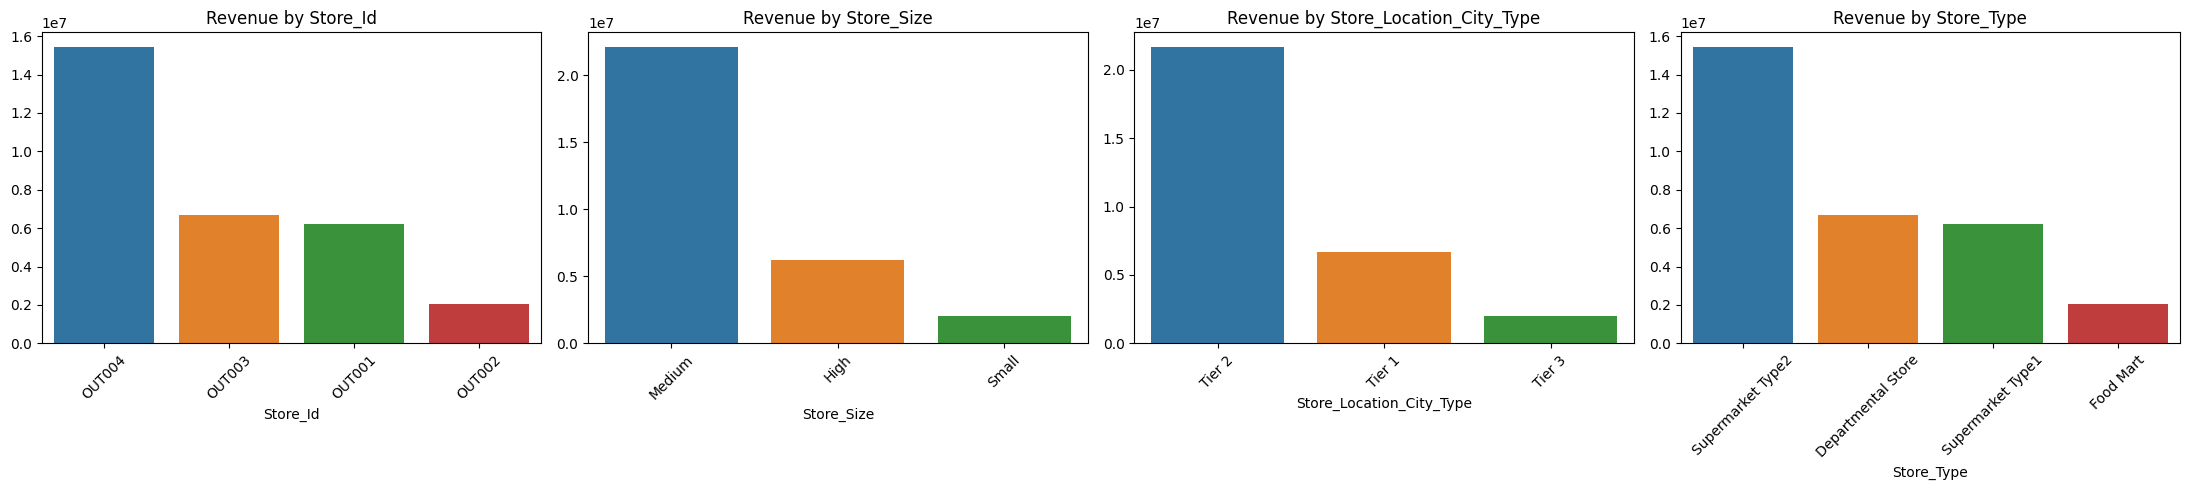

In [30]:
# Revenue per store and per store attribute, shown side by side
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, col in zip(axes, ["Store_Id", "Store_Size", "Store_Location_City_Type", "Store_Type"]):
    rev = data.groupby(col)["Product_Store_Sales_Total"].sum().sort_values(ascending=False)
    sns.barplot(x=rev.index, y=rev.values, hue=rev.index, legend=False, ax=ax)
    ax.set_title(f"Revenue by {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Store-level summary: revenue, share, number of products and average sales per product
store_summary = data.groupby(["Store_Id", "Store_Type", "Store_Size", "Store_Location_City_Type", "Store_Establishment_Year"]).agg(
    Revenue=("Product_Store_Sales_Total", "sum"),
    Products=("Product_Id", "count"),
    Avg_Sales_per_Product=("Product_Store_Sales_Total", "mean"),
    Avg_MRP=("Product_MRP", "mean"),
).reset_index()
store_summary["Revenue_Share_%"] = (store_summary["Revenue"] / store_summary["Revenue"].sum() * 100).round(1)
store_summary.round(1)

,Store_Id,Store_Type,Store_Size,Store_Location_City_Type,Store_Establishment_Year,Revenue,Products,Avg_Sales_per_Product,Avg_MRP,Revenue_Share_%
0,OUT001,Supermarket Type1,High,Tier 2,1987,6223113.2,1586,3923.8,160.5,20.5
1,OUT002,Food Mart,Small,Tier 3,1998,2030909.7,1152,1762.9,107.1,6.7
2,OUT003,Departmental Store,Medium,Tier 1,1999,6673457.6,1349,4947.0,181.4,22.0
3,OUT004,Supermarket Type2,Medium,Tier 2,2009,15427583.4,4676,3299.3,142.4,50.8


- **OUT004** (Supermarket Type2, Medium, Tier 2, est. 2009) earns the most: ≈ **15.43 M (50.8%)** of total revenue - driven by volume (4,676 products) rather than value per product (avg ≈ 3,299).
- **OUT003** (Departmental Store, Medium, Tier 1, est. 1999) has the **highest sales per product (≈ 4,947)** and the highest average MRP (≈ 181) - a premium store.
- **OUT001** (Supermarket Type1, High, Tier 2, est. 1987) earns ≈ 6.22 M with avg ≈ 3,924 per product.
- **OUT002** (Food Mart, Small, Tier 3, est. 1998) is the weakest: ≈ 2.03 M (6.7%) with avg ≈ 1,763 per product and the lowest average MRP (≈ 107).

### Distribution of sales across stores and store sizes

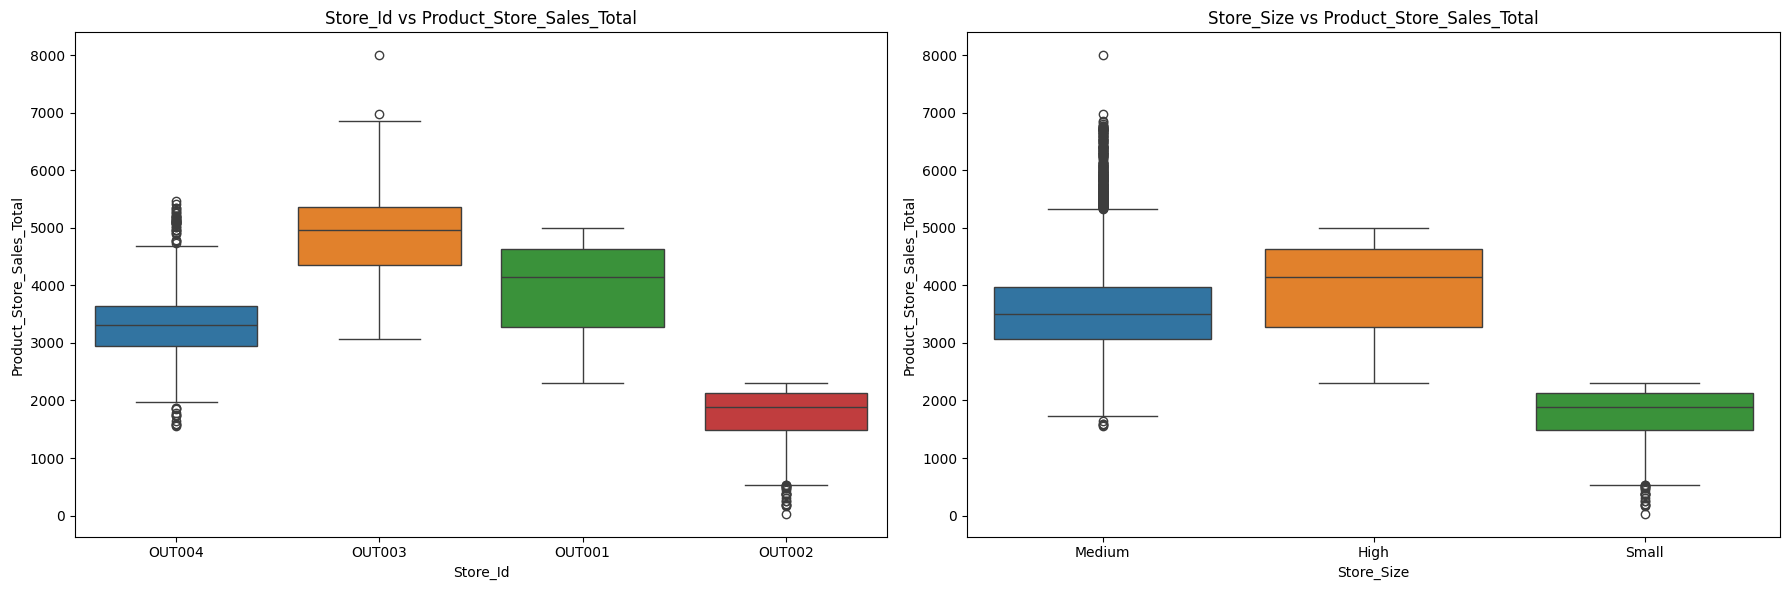

In [32]:
# Boxplots of product-level sales per store and per store size
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue="Store_Id", ax=axes[0])
axes[0].set_title("Store_Id vs Product_Store_Sales_Total")
sns.boxplot(data=data, x="Store_Size", y="Product_Store_Sales_Total", hue="Store_Size", ax=axes[1])
axes[1].set_title("Store_Size vs Product_Store_Sales_Total")
plt.tight_layout()
plt.show()

- The sales distribution is clearly shifted by store: **OUT003 > OUT001 > OUT004 > OUT002** in median sales per product.
- Small stores (OUT002) sell much less per product; Medium stores show the widest spread because they combine OUT003 (premium) and OUT004 (volume).

### Relationships between product attributes

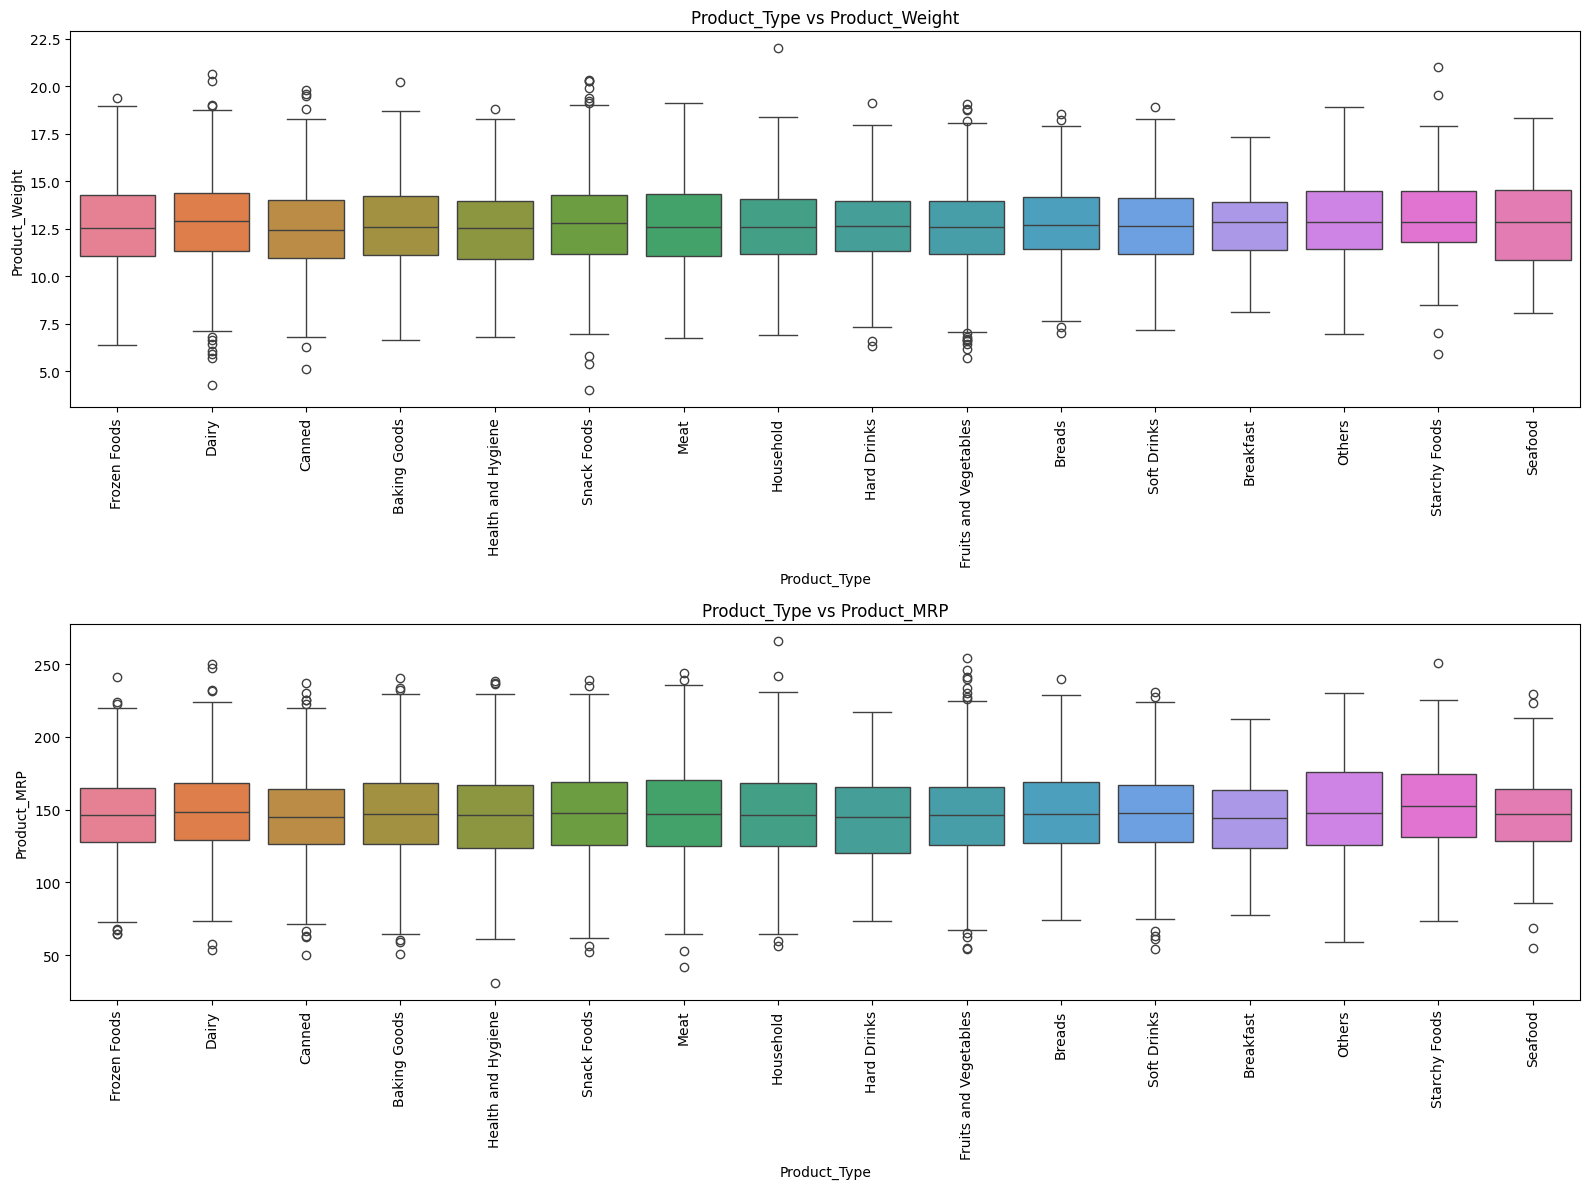

In [33]:
# Product weight and MRP by product type
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
sns.boxplot(data=data, x="Product_Type", y="Product_Weight", hue="Product_Type", ax=axes[0])
axes[0].set_title("Product_Type vs Product_Weight")
sns.boxplot(data=data, x="Product_Type", y="Product_MRP", hue="Product_Type", ax=axes[1])
axes[1].set_title("Product_Type vs Product_MRP")
for ax in axes:
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

- Median weight (≈ 12.4 – 12.9) and median MRP (≈ 144 – 153) are almost identical across product types - product type alone does not decide price or weight; Starchy Foods has a slightly higher median MRP.

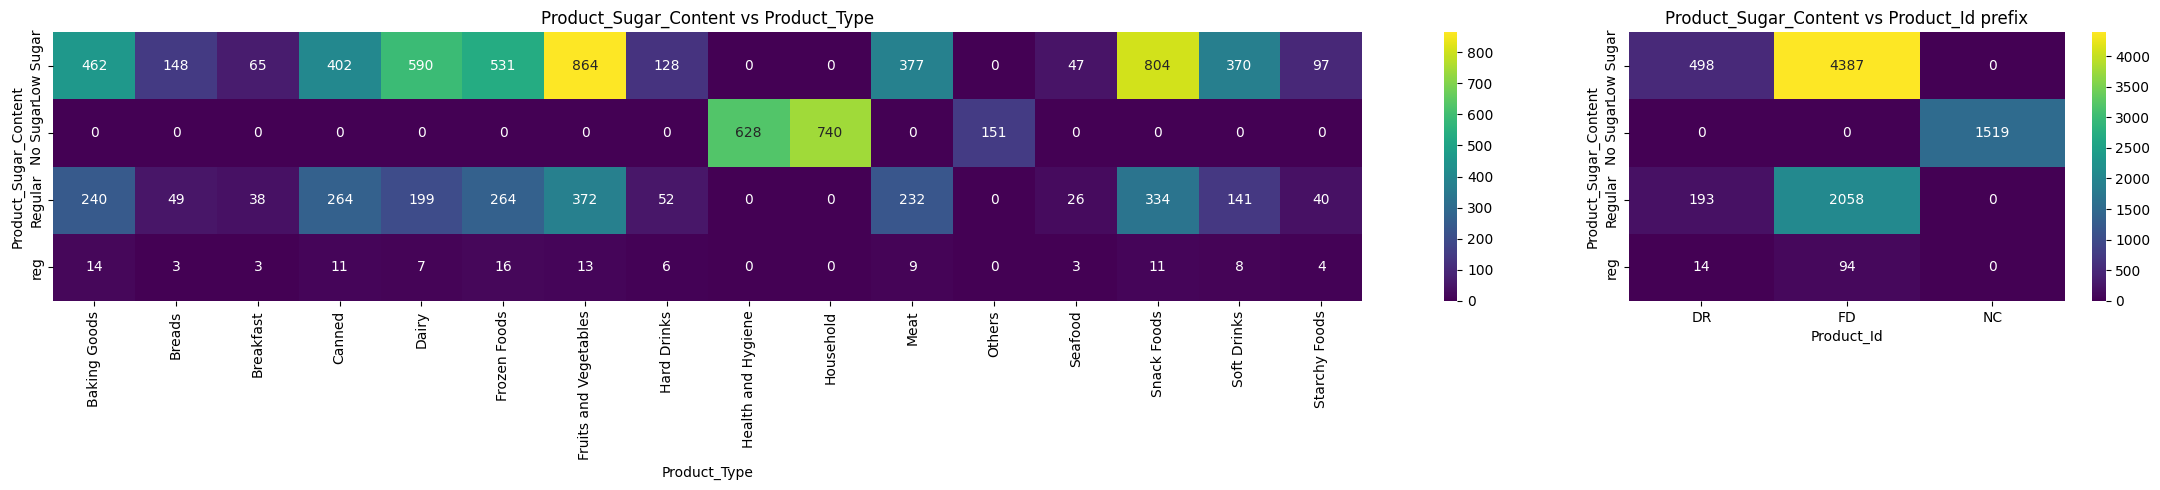

In [34]:
# Sugar content vs product type (counts) and vs product-ID prefix
fig, axes = plt.subplots(1, 2, figsize=(22, 5), gridspec_kw={"width_ratios": (3, 1)})
sns.heatmap(pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]), annot=True, fmt="g", cmap="viridis", ax=axes[0])
axes[0].set_title("Product_Sugar_Content vs Product_Type")
sns.heatmap(pd.crosstab(data["Product_Sugar_Content"], data["Product_Id"].str[:2]), annot=True, fmt="g", cmap="viridis", ax=axes[1])
axes[1].set_title("Product_Sugar_Content vs Product_Id prefix")
plt.tight_layout()
plt.show()

- **All "No Sugar" items are non-consumables** (Health and Hygiene, Household, Others - Product_Id prefix `NC`); food and drink items are either Low Sugar or Regular.

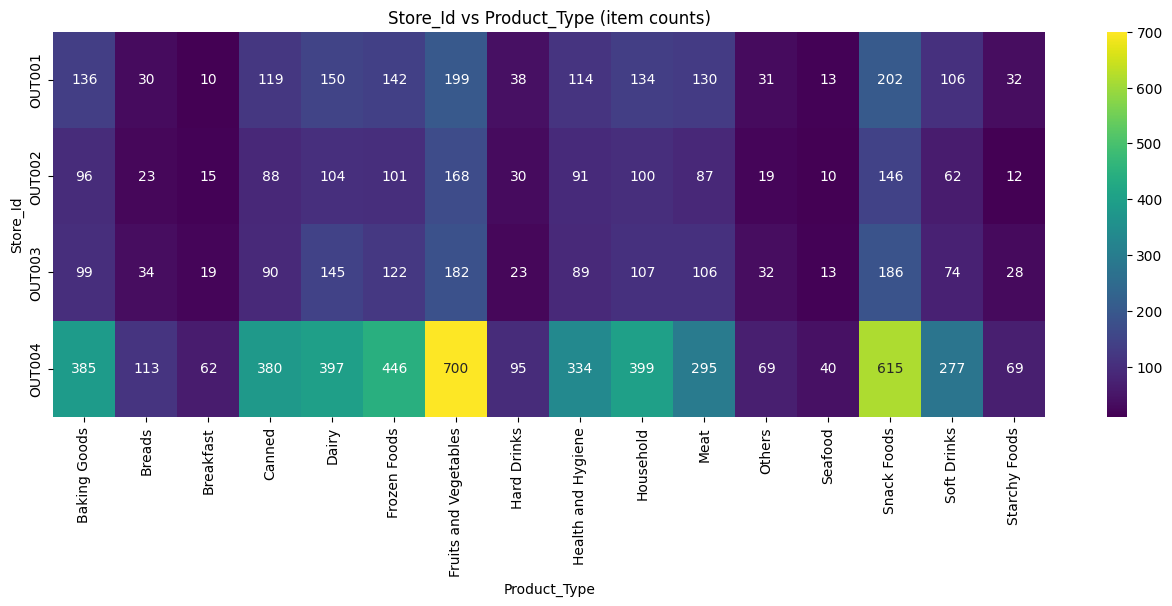

In [35]:
# How many items of each product type are sold in each store
plt.figure(figsize=(16, 5))
sns.heatmap(pd.crosstab(data["Store_Id"], data["Product_Type"]), annot=True, fmt="g", cmap="viridis")
plt.title("Store_Id vs Product_Type (item counts)")
plt.show()

- Every store carries all 16 product types; the mix is similar across stores, with Fruits and Vegetables and Snack Foods the top two everywhere. OUT004 has the largest count in every category.

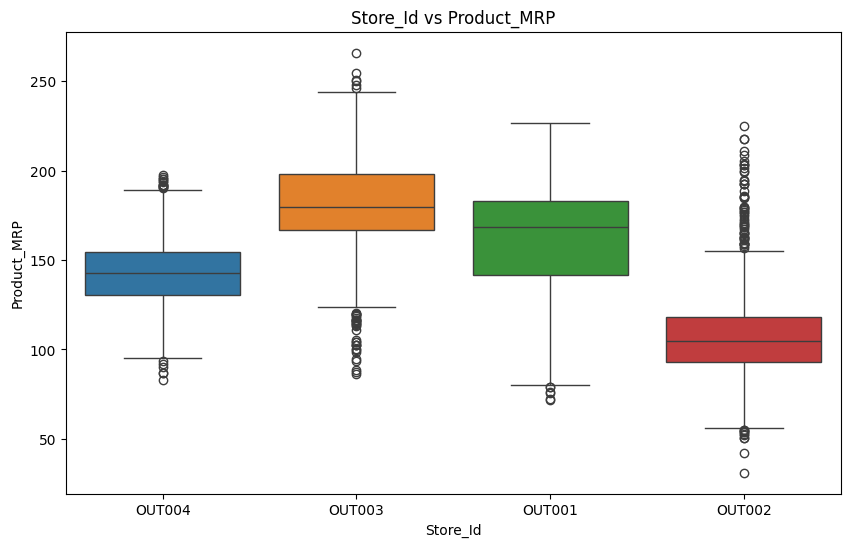

In [36]:
# Product MRP by store
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="Store_Id", y="Product_MRP", hue="Store_Id")
plt.title("Store_Id vs Product_MRP")
plt.show()

- **OUT003 sells the most expensive products** (median MRP ≈ 180, up to 266) and **OUT002 the cheapest** (median ≈ 105). Price positioning differs by store and explains a large part of the sales gap between them.

In [37]:
# Top 2 product types by revenue within each store
top_by_store = (
    data.groupby(["Store_Id", "Product_Type"])["Product_Store_Sales_Total"].sum()
    .groupby(level=0, group_keys=False).nlargest(2).round(0)
)
top_by_store

Store_Id  Product_Type         
OUT001    Snack Foods               806142.0
          Fruits and Vegetables     792993.0
OUT002    Fruits and Vegetables     298504.0
          Snack Foods               255318.0
OUT003    Snack Foods               918510.0
          Fruits and Vegetables     897437.0
OUT004    Fruits and Vegetables    2311900.0
          Snack Foods              2009027.0
Name: Product_Store_Sales_Total, dtype: float64

- In every store the top-2 revenue categories are **Fruits and Vegetables and Snack Foods** (OUT004: 2.31 M and 2.01 M; OUT003: 0.92 M and 0.90 M; OUT001: 0.81 M and 0.79 M; OUT002: 0.30 M and 0.26 M).

# **Data Preprocessing**

## Fixing inconsistent sugar-content labels

In [38]:
# 'reg' is the same category as 'Regular' - merge them
data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace("reg", "Regular")
data["Product_Sugar_Content"].value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## Feature engineering

**1. Product-ID prefix** - the first two characters of `Product_Id` encode a product family.

In [39]:
# Extract the first two characters of Product_Id
data["Product_Id_char"] = data["Product_Id"].str[:2]

# Check which product types sit behind each prefix
data.groupby("Product_Id_char")["Product_Type"].unique()

,Product_Type
Product_Id_char,
DR,"[Hard Drinks, Soft Drinks]"
FD,"[Frozen Foods, Dairy, Canned, Baking Goods, Sn..."
NC,"[Health and Hygiene, Household, Others]"


- `FD` = food items, `DR` = drinks (Hard Drinks, Soft Drinks), `NC` = non-consumables (Health and Hygiene, Household, Others). This is a useful, low-cardinality summary of the 16 product types.

**2. Store age** - older stores have an established customer base.

In [40]:
# Store age relative to 2025 (the reference year used in the API payload and batch file)
data["Store_Age_Years"] = 2025 - data["Store_Establishment_Year"]
data["Store_Age_Years"].value_counts()

,count
Store_Age_Years,
16,4676
38,1586
26,1349
27,1152


**3. Perishable vs non-perishable** - reduces 16 product types to 2 business-relevant groups (perishables need faster replenishment).

In [41]:
# Product types that spoil quickly
perishables = ["Dairy", "Meat", "Fruits and Vegetables", "Breakfast", "Breads", "Seafood"]

# Map every product type to its category
data["Product_Type_Category"] = np.where(
    data["Product_Type"].isin(perishables), "Perishables", "Non Perishables"
)
data.groupby("Product_Type_Category")["Product_Store_Sales_Total"].agg(["count", "sum"])

,count,sum
Product_Type_Category,,
Non Perishables,5718,19763623.96
Perishables,3045,10591439.94


- Non-perishables account for 5,718 products and ≈ 19.8 M revenue (65%); perishables for 3,045 products and ≈ 10.6 M (35%).

## Outlier check

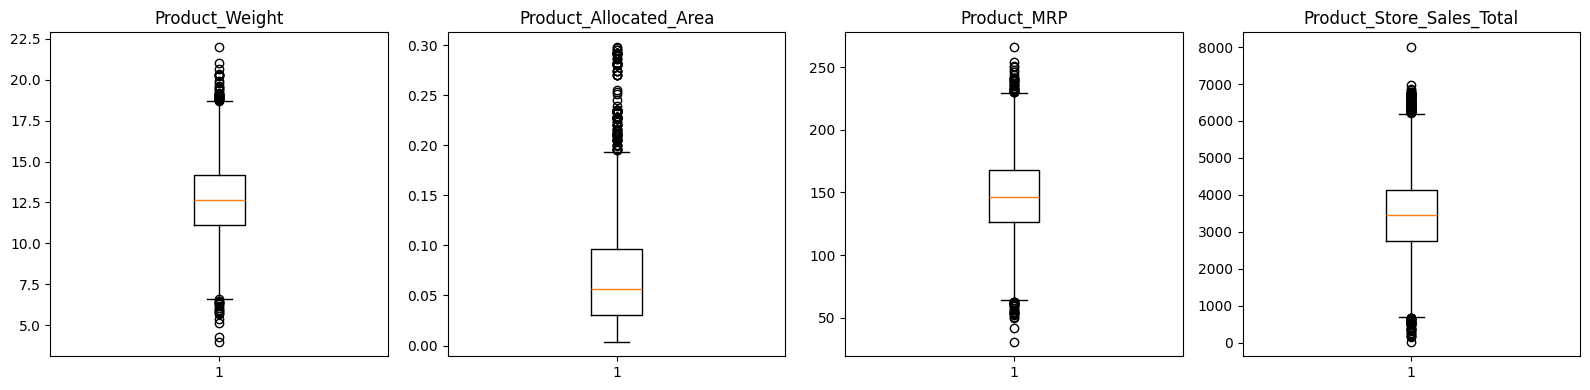

,0
Product_Weight,54
Product_Allocated_Area,104
Product_MRP,57
Product_Store_Sales_Total,119


In [42]:
# Boxplots of numeric columns to look for outliers
outlier_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]
plt.figure(figsize=(16, 4))
for i, col in enumerate(outlier_cols):
    plt.subplot(1, 4, i + 1)
    plt.boxplot(data[col], whis=1.5)
    plt.title(col)
plt.tight_layout()
plt.show()

# Count of IQR outliers per column
q1, q3 = data[outlier_cols].quantile(0.25), data[outlier_cols].quantile(0.75)
iqr = q3 - q1
((data[outlier_cols] < q1 - 1.5 * iqr) | (data[outlier_cols] > q3 + 1.5 * iqr)).sum()

- Each numeric column has a small number of IQR outliers (54 – 119 rows, ≤ 1.4%). They are plausible values (real prices, weights, shelf shares and sales), so they are **not removed or capped**; tree-based models are robust to them.

## Data preparation for modeling

In [43]:
# Drop columns that are identifiers or have been replaced by engineered features:
# - Product_Id: unique per row (replaced by Product_Id_char)
# - Product_Type: 16 levels (summarised by Product_Type_Category and Product_Id_char)
# - Store_Id: fully described by Store_Size / Store_Location_City_Type / Store_Type
# - Store_Establishment_Year: replaced by Store_Age_Years
model_data = data.drop(["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"], axis=1)

# Separate the features (X) and the target (y)
X = model_data.drop("Product_Store_Sales_Total", axis=1)
y = model_data["Product_Store_Sales_Total"]

# 70:30 train-test split with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, shuffle=True)
print("Train:", X_train.shape, " Test:", X_test.shape)
X_train.head()

Train: (6134, 10)  Test: (2629, 10)


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
910,11.73,Regular,0.071,132.08,Medium,Tier 2,Supermarket Type2,FD,16,Non Perishables
7022,11.61,Regular,0.062,150.70,Medium,Tier 2,Supermarket Type2,DR,16,Non Perishables
8056,11.30,Low Sugar,0.039,102.35,Small,Tier 3,Food Mart,FD,27,Perishables
2939,12.55,Low Sugar,0.095,139.35,Medium,Tier 2,Supermarket Type2,FD,16,Perishables
68,12.95,Regular,0.076,155.55,Medium,Tier 2,Supermarket Type2,FD,16,Perishables


### Preprocessing pipeline

In [44]:
# Identify categorical and numerical feature columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

# One-hot encode categorical features; handle_unknown="ignore" lets the deployed model
# accept category values it has not seen in training (e.g. "Supermarket Type3").
# remainder="passthrough" keeps the numeric columns - without it, make_column_transformer
# silently DROPS every column not listed, and the model would lose weight and MRP.
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    remainder="passthrough",
)

Categorical: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category']
Numerical: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']


- Scaling is not applied because tree-based models are not sensitive to feature scale.
- Encoding lives inside the pipeline, so the same transformation is applied at training time and at prediction time in the deployed API - raw feature values can be sent to the model directly.

# **Model Building**

## Define functions for Model Evaluation

In [45]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

**Evaluation metric**
- The model is optimised for **R²** (share of the variation in sales explained) and also reports **RMSE** (typical error in sales units, penalises large misses), MAE and MAPE (average % error - easy for business users to interpret).
- Two models are built: **Random Forest** (bagging of deep trees - robust, low variance) and **XGBoost** (gradient boosting - often the most accurate on tabular data).

## Random Forest

In [46]:
# Random Forest with default hyperparameters inside the preprocessing pipeline
rf_estimator = make_pipeline(preprocessor, RandomForestRegressor(random_state=1))
rf_estimator.fit(X_train, y_train)

# Performance on the training and test sets
rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
print("Training performance:")
display(rf_estimator_model_train_perf)
print("Test performance:")
display(rf_estimator_model_test_perf)

Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,104.566026,39.946068,0.990337,0.990321,0.014121


Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,295.940703,112.705907,0.923467,0.923174,0.050206


- Train R² ≈ 0.99 vs test R² ≈ 0.92 (RMSE 105 vs 296): the default forest grows fully deep trees and **overfits** the training data, although test performance is already good.

## XGBoost

In [47]:
# XGBoost with default hyperparameters inside the preprocessing pipeline
xgb_estimator = make_pipeline(preprocessor, XGBRegressor(random_state=1))
xgb_estimator.fit(X_train, y_train)

# Performance on the training and test sets
xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
print("Training performance:")
display(xgb_estimator_model_train_perf)
print("Test performance:")
display(xgb_estimator_model_test_perf)

Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,118.628943,58.099567,0.987563,0.987542,0.019789


Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,309.448421,138.03274,0.916321,0.916001,0.056671


- Train R² ≈ 0.99 vs test R² ≈ 0.92 (RMSE 119 vs 309): default XGBoost also **overfits** and is slightly weaker than the default Random Forest on the test set.

# **Model Performance Improvement - Hyperparameter Tuning**

- `GridSearchCV` with **3-fold cross-validation** on the training data, optimising `scoring="r2"`.
- Note: `scoring` must be the string `"r2"` (or a scorer made with `make_scorer`). Passing the metric function `r2_score` directly makes every fit fail silently (all CV scores become NaN) and the "best" model is chosen arbitrarily.

## Tuning Random Forest

In [48]:
# Pipeline to tune
rf_tuned = make_pipeline(preprocessor, RandomForestRegressor(random_state=1))

# Grid: limiting depth and features per split controls overfitting; more trees reduce variance
rf_params = {
    "randomforestregressor__max_depth": [4, 6, 8, 10, None],
    "randomforestregressor__max_features": ["sqrt", 0.5, 1.0],
    "randomforestregressor__n_estimators": [50, 100, 200],
}

# 3-fold CV grid search on the training data
rf_grid = GridSearchCV(rf_tuned, rf_params, scoring="r2", cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best parameters:", rf_grid.best_params_)
print("Best CV R2:", round(rf_grid.best_score_, 4))

# Keep the best pipeline (GridSearchCV refits it on the full training set)
rf_tuned = rf_grid.best_estimator_

rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Training performance:")
display(rf_tuned_model_train_perf)
print("Test performance:")
display(rf_tuned_model_test_perf)

Best parameters: {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': 1.0, 'randomforestregressor__n_estimators': 200}
Best CV R2: 0.9285
Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,185.204057,74.41193,0.969686,0.969636,0.02493


Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,290.789943,114.630365,0.926108,0.925825,0.051492


- Best parameters: `max_depth=10`, `max_features=1.0`, `n_estimators=200` (CV R² ≈ 0.929).
- The train–test gap shrinks (train R² 0.97 vs test R² 0.926) and **test RMSE improves from ≈ 296 to ≈ 291**, with test MAPE ≈ 5.2%.

## Tuning XGBoost

In [49]:
# Pipeline to tune
xgb_tuned = make_pipeline(preprocessor, XGBRegressor(random_state=1))

# Grid: number of trees, learning rate and depth trade off bias vs variance;
# subsample / colsample_bytree add randomness that reduces overfitting
xgb_params = {
    "xgbregressor__n_estimators": [50, 100, 200],
    "xgbregressor__max_depth": [3, 5, 7],
    "xgbregressor__learning_rate": [0.05, 0.1],
    "xgbregressor__subsample": [0.7, 1.0],
    "xgbregressor__colsample_bytree": [0.7, 1.0],
}

# 3-fold CV grid search on the training data
xgb_grid = GridSearchCV(xgb_tuned, xgb_params, scoring="r2", cv=3, n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("Best parameters:", xgb_grid.best_params_)
print("Best CV R2:", round(xgb_grid.best_score_, 4))

# Keep the best pipeline
xgb_tuned = xgb_grid.best_estimator_

xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Training performance:")
display(xgb_tuned_model_train_perf)
print("Test performance:")
display(xgb_tuned_model_test_perf)

Best parameters: {'xgbregressor__colsample_bytree': 1.0, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 100, 'xgbregressor__subsample': 0.7}
Best CV R2: 0.9276
Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,208.914698,81.57351,0.961427,0.961364,0.028284


Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,291.176486,113.116303,0.925911,0.925628,0.049999


- Best parameters: `learning_rate=0.05`, `max_depth=7`, `n_estimators=100`, `subsample=0.7`, `colsample_bytree=1.0` (CV R² ≈ 0.928).
- Overfitting is reduced (train R² 0.96 vs test R² 0.926) and **test RMSE improves from ≈ 309 to ≈ 291**.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [50]:
# Side-by-side comparison of all four models
model_names = ["Random Forest", "Random Forest Tuned", "XGBoost", "XGBoost Tuned"]

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T, rf_tuned_model_train_perf.T,
     xgb_estimator_model_train_perf.T, xgb_tuned_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = model_names

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T, rf_tuned_model_test_perf.T,
     xgb_estimator_model_test_perf.T, xgb_tuned_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = model_names

print("Training performance comparison:")
display(models_train_comp_df.round(4))
print("Test performance comparison:")
display(models_test_comp_df.round(4))

# Difference between train and test R2 -> a measure of overfitting
(models_train_comp_df.loc["R-squared"] - models_test_comp_df.loc["R-squared"]).round(4).rename("Train-Test R2 gap")

Training performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,104.5660,185.2041,118.6289,208.9147
MAE,39.9461,74.4119,58.0996,81.5735
R-squared,0.9903,0.9697,0.9876,0.9614
Adj. R-squared,0.9903,0.9696,0.9875,0.9614
MAPE,0.0141,0.0249,0.0198,0.0283


Test performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,295.9407,290.7899,309.4484,291.1765
MAE,112.7059,114.6304,138.0327,113.1163
R-squared,0.9235,0.9261,0.9163,0.9259
Adj. R-squared,0.9232,0.9258,0.9160,0.9256
MAPE,0.0502,0.0515,0.0567,0.0500


,Train-Test R2 gap
Random Forest,0.0669
Random Forest Tuned,0.0436
XGBoost,0.0712
XGBoost Tuned,0.0355


**Final model selection**
- Both tuned models reach test R² ≈ 0.926 and RMSE ≈ 291, clearly better than their default versions.
- **Tuned Random Forest is selected**: it has the lowest test RMSE (≈ 290.8) and the highest test R² (≈ 0.926), with test MAPE ≈ 5.2%, and generalises consistently (CV R² 0.929 ≈ test R² 0.926). Tuned XGBoost has a slightly smaller train–test gap (0.036 vs 0.044), but its test error is marginally higher. The two tuned models are within ~0.5 RMSE of each other, so either would be acceptable in production.
- In business terms, the model's typical error is ≈ 291 on an average product-store sale of ≈ 3,464 (~5% average error).

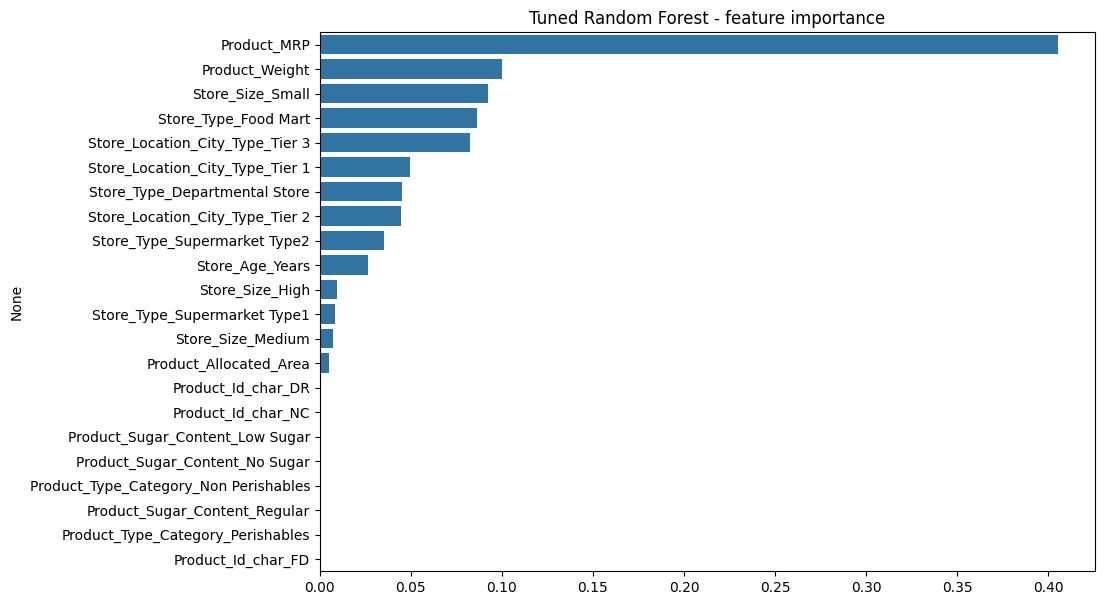

,0
remainder__Product_MRP,0.4053
remainder__Product_Weight,0.1000
onehotencoder__Store_Size_Small,0.0922
onehotencoder__Store_Type_Food Mart,0.0863
onehotencoder__Store_Location_City_Type_Tier 3,0.0825
onehotencoder__Store_Location_City_Type_Tier 1,0.0495
onehotencoder__Store_Type_Departmental Store,0.0450
onehotencoder__Store_Location_City_Type_Tier 2,0.0448


In [51]:
# Which features drive the final model?
final_model = rf_tuned
feature_names = final_model.named_steps["columntransformer"].get_feature_names_out()
importances = pd.Series(
    final_model.named_steps["randomforestregressor"].feature_importances_, index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index.str.replace("onehotencoder__", "").str.replace("remainder__", ""))
plt.title("Tuned Random Forest - feature importance")
plt.show()
importances.head(8).round(4)

- **Product_MRP (≈ 0.41)** is by far the most important feature, followed by **Product_Weight (≈ 0.10)**.
- The next most important features are the store dummies that identify the small Tier 3 Food Mart (OUT002) and the Tier 1 Departmental Store (OUT003) - i.e. *which kind of store* a product is sold in.
- Product allocated area, sugar content and product category add very little predictive value.

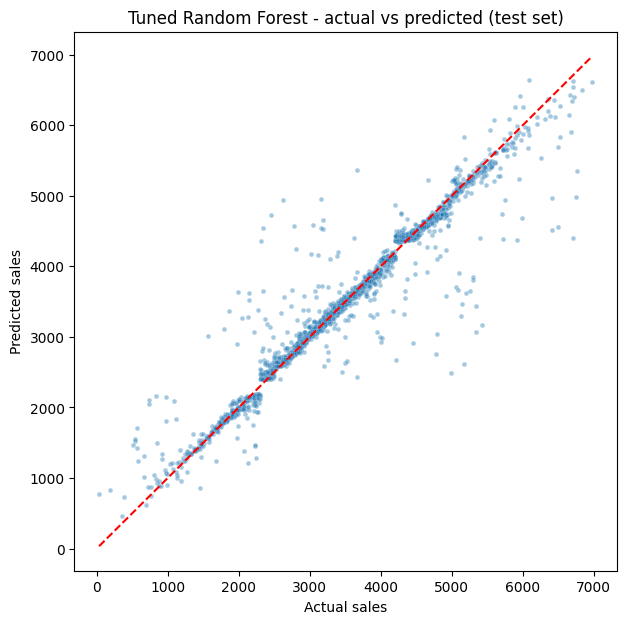

In [52]:
# Actual vs predicted on the test set for the final model
test_pred = final_model.predict(X_test)
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=test_pred, alpha=0.4, s=12)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Tuned Random Forest - actual vs predicted (test set)")
plt.show()

- Predictions sit tightly along the 45° line across the full sales range, with no systematic bias for low or high sales.

## Serialization

In [53]:
# Folder that will hold all backend (Flask API) files
os.makedirs("backend_files", exist_ok=True)

# Save the full pipeline (preprocessing + model) so the API can take raw feature values
saved_model_path = "backend_files/superkart_model.joblib"
joblib.dump(final_model, saved_model_path)
print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/superkart_model.joblib


In [54]:
# Reload the model from disk and confirm it gives identical predictions without retraining
saved_model = joblib.load(saved_model_path)
reloaded_pred = saved_model.predict(X_test)
print("Model loaded successfully.")
print("Predictions identical to in-memory model:", np.allclose(reloaded_pred, test_pred))
reloaded_pred[:5]

Model loaded successfully.
Predictions identical to in-memory model: True


array([3717.50252238, 5880.01868882, 4478.98055735, 3426.40968977,
       4155.10609952])

- The pipeline (one-hot encoding + tuned Random Forest) was saved to `backend_files/superkart_model.joblib` and reloaded; the reloaded model's predictions are identical to the in-memory model's, so it can be used by the API without retraining.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [55]:
%%writefile backend_files/app.py
# ------------------------------------------------------------
# SuperKart sales-forecast REST API (Flask)
# ------------------------------------------------------------
import joblib                                  # load the serialized pipeline
import pandas as pd                            # build model input DataFrames
from flask import Flask, request, jsonify      # web framework

# Create the Flask application
superkart_api = Flask("SuperKart")

# Load the trained pipeline once at start-up (preprocessing + tuned Random Forest)
model = joblib.load("superkart_model.joblib")

# Features the model expects, in training order
FEATURES = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP",
    "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char",
    "Store_Age_Years", "Product_Type_Category",
]


@superkart_api.get("/")
def home():
    """Health-check / landing route."""
    return "Welcome to the SuperKart Sales Forecast API"


@superkart_api.post("/v1/predict")
def predict_sales():
    """Online inference: predict sales for one product-store record sent as JSON."""
    data = request.get_json(silent=True)
    if data is None:
        return jsonify({"error": "Request body must be JSON"}), 400

    # Reject requests with missing features
    missing = [f for f in FEATURES if f not in data]
    if missing:
        return jsonify({"error": f"Missing features: {missing}"}), 400

    # Build a one-row DataFrame in the expected column order
    input_data = pd.DataFrame([{f: data[f] for f in FEATURES}])

    # Predict and return the value rounded to 2 decimals
    prediction = float(model.predict(input_data)[0])
    return jsonify({"Sales": round(prediction, 2)})


@superkart_api.post("/v1/predictbatch")
def predict_sales_batch():
    """Batch inference: predict sales for every row of an uploaded CSV file."""
    if "file" not in request.files:
        return jsonify({"error": "Upload a CSV file under the key 'file'"}), 400

    # Read the uploaded CSV into a DataFrame
    input_data = pd.read_csv(request.files["file"])

    missing = [f for f in FEATURES if f not in input_data.columns]
    if missing:
        return jsonify({"error": f"Missing columns: {missing}"}), 400

    # Predict for all rows at once
    predictions = model.predict(input_data[FEATURES])

    # Map row index -> predicted sales
    return jsonify({str(i): round(float(p), 2) for i, p in enumerate(predictions)})


# Local development entry point (in Docker the app is served by gunicorn)
if __name__ == "__main__":
    superkart_api.run(host="0.0.0.0", port=7860, debug=False)

Writing backend_files/app.py


- `GET /` - health check.
- `POST /v1/predict` - JSON body with the 10 features → `{"Sales": value}`.
- `POST /v1/predictbatch` - CSV upload under the key `file` → `{"0": value, "1": value, ...}`.
- Basic input validation returns HTTP 400 with a clear message instead of crashing on bad requests.

## Dependencies File

In [57]:
%%writefile backend_files/requirements.txt
# Backend dependencies - versions pinned to match the training environment
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==23.0.0
requests==2.32.4

Overwriting backend_files/requirements.txt


- Library versions match the training environment, so the pickled pipeline loads without version-mismatch errors.

## Dockerfile

In [58]:
%%writefile backend_files/Dockerfile
# Lightweight Python base image
FROM python:3.12-slim

# Working directory inside the container
WORKDIR /app

# Copy app.py, requirements.txt and superkart_model.joblib into the image
COPY . .

# Install dependencies without caching wheels (smaller image)
RUN pip install --no-cache-dir -r requirements.txt

# Serve the Flask app with gunicorn: 4 workers, listening on port 7860 on all interfaces
EXPOSE 7860
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [59]:
# Folder that will hold all frontend (Streamlit) files
os.makedirs("frontend_files", exist_ok=True)

In [60]:
%%writefile frontend_files/app.py
# ------------------------------------------------------------
# SuperKart sales-forecast UI (Streamlit)
# ------------------------------------------------------------
import os
import pandas as pd
import requests
import streamlit as st

# Backend address: "backend" is the Flask container name on the shared Docker network.
# It can be overridden with the BACKEND_URL environment variable.
BACKEND_URL = os.getenv("BACKEND_URL", "http://backend:7860")

st.set_page_config(page_title="SuperKart Sales Forecast", page_icon="🛒")
st.title("SuperKart Sales Forecast")
st.write("Enter product and store details to forecast the total sales of a product in a store.")

# ---------------- Single prediction ----------------
st.subheader("Single prediction")
col1, col2 = st.columns(2)
with col1:
    Product_Weight = st.number_input("Product Weight", min_value=0.0, max_value=50.0, value=12.66)
    Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
    Product_Allocated_Area = st.number_input("Product Allocated Area (0-1)", min_value=0.0, max_value=1.0, value=0.027, format="%.3f")
    Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
    Product_Id_char = st.selectbox("Product ID Prefix (FD=Food, DR=Drinks, NC=Non-consumable)", ["FD", "DR", "NC"])
with col2:
    Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
    Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
    Store_Age_Years = st.number_input("Store Age (Years)", min_value=0, max_value=100, value=16)
    Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

# JSON payload for the API
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category,
}

if st.button("Predict", type="primary"):
    try:
        response = requests.post(f"{BACKEND_URL}/v1/predict", json=product_data, timeout=30)
        if response.status_code == 200:
            st.success(f"Predicted Product Store Sales Total: {response.json()['Sales']:,.2f}")
        else:
            st.error(f"API error {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"Unable to reach the prediction API: {e}")

# ---------------- Batch prediction ----------------
st.subheader("Batch prediction")
uploaded_file = st.file_uploader("Upload a CSV file with the 10 feature columns", type=["csv"])

if uploaded_file is not None and st.button("Predict for Batch", type="primary"):
    try:
        response = requests.post(f"{BACKEND_URL}/v1/predictbatch", files={"file": uploaded_file.getvalue()}, timeout=60)
        if response.status_code == 200:
            # Attach predictions to the uploaded rows so users see inputs and outputs together
            uploaded_file.seek(0)
            result_df = pd.read_csv(uploaded_file)
            preds = response.json()
            result_df["Predicted_Sales"] = [preds[str(i)] for i in range(len(result_df))]
            st.success("Predictions completed successfully!")
            st.dataframe(result_df, use_container_width=True)
            # Let the user download the results
            st.download_button("Download predictions", result_df.to_csv(index=False), "superkart_predictions.csv", "text/csv")
        else:
            st.error(f"API error {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"Unable to reach the prediction API: {e}")

Writing frontend_files/app.py


- The UI offers a form for a single prediction and a CSV upload for batch predictions; both call the Flask backend.
- Batch results are shown next to the uploaded inputs and can be downloaded as CSV.

## Dependencies File

In [61]:
%%writefile frontend_files/requirements.txt
# Frontend dependencies - the UI only needs pandas, requests and streamlit
pandas==2.2.3
requests==2.32.4
streamlit==1.43.2

Writing frontend_files/requirements.txt


## Dockerfile

In [62]:
%%writefile frontend_files/Dockerfile
# Lightweight Python base image
FROM python:3.12-slim

# Working directory inside the container
WORKDIR /app

# Copy app.py and requirements.txt into the image
COPY . .

# Install Python dependencies
RUN pip3 install --no-cache-dir -r requirements.txt

# Run Streamlit on port 8501, reachable from outside the container
EXPOSE 8501
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

The cell below creates a public GitHub repository and uploads the backend and frontend files:

```
superkart-sales-forecast/
├── backend/   app.py, requirements.txt, Dockerfile, superkart_model.joblib
└── frontend/  app.py, requirements.txt, Dockerfile
```

The Personal Access Token is read from a Colab Secret named `Gittoken` (or the `GITHUB_TOKEN` environment variable) - it is never hard-coded in the notebook.

In [63]:
# Install the GitHub API client used to create the repository and upload files
!pip install PyGithub==2.6.1 -q

In [69]:
# Read the GitHub token securely (Colab Secret first, then environment variable)
try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get("Gittoken")
except Exception:
    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")

REPO_NAME = "superkart-sales-forecast"

# Map of repository paths -> local files to upload
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model.joblib": "backend_files/superkart_model.joblib",
    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}

if not GITHUB_TOKEN:
    print("No GitHub token found - add a Colab Secret named 'Gittoken' and re-run this cell.")
else:
    from github import Github, GithubException

    g = Github(GITHUB_TOKEN)
    user = g.get_user()
    print(f"Authenticated as: {user.login}")

    # Re-use the repository if it already exists, otherwise create it
    try:
        repo = user.get_repo(REPO_NAME)
        print(f"Using existing repository: {repo.html_url}")
    except GithubException:
        repo = user.create_repo(REPO_NAME, description="SuperKart sales forecast - Flask API + Streamlit UI", private=False, auto_init=True)
        print(f"Repository created: {repo.html_url}")

    # Upload each file (update it if it is already there)
    for repo_path, local_path in files_to_push.items():
        with open(local_path, "rb") as f:
            content = f.read()
        try:
            existing = repo.get_contents(repo_path, ref="main")
            repo.update_file(repo_path, f"Update {repo_path}", content, existing.sha, branch="main")
        except GithubException:
            repo.create_file(repo_path, f"Add {repo_path}", content, branch="main")
        print(f"Uploaded: {repo_path}")

    print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: ravikanthd1981
Repository created: https://github.com/ravikanthd1981/superkart-sales-forecast
Uploaded: backend/app.py
Uploaded: backend/requirements.txt
Uploaded: backend/Dockerfile
Uploaded: backend/superkart_model.joblib
Uploaded: frontend/app.py
Uploaded: frontend/requirements.txt
Uploaded: frontend/Dockerfile

All files pushed successfully to: https://github.com/ravikanthd1981/superkart-sales-forecast


## Running both containers in a GitHub Codespace

Open the repository → **Code → Codespaces → Create codespace on main**, then in the Codespace terminal:

```bash
# 1. Create a network so the two containers can reach each other by name
docker network create superkart-net

# 2. Build and start the Flask backend (container name "backend", port 7860)
docker build -t superkart-backend ./backend
docker run -d --name backend --network superkart-net -p 7860:7860 superkart-backend

# 3. Build and start the Streamlit frontend (port 8501); it calls http://backend:7860
docker build -t superkart-frontend ./frontend
docker run -d --name frontend --network superkart-net -p 8501:8501 superkart-frontend

# 4. Check both containers are running
docker ps
```

In the **Ports** tab set ports **7860** and **8501** to **Public** and copy the forwarded URLs.

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [118]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [174]:
# Forwarded URL of port 7860 from the Codespace Ports tab (no trailing slash),
# e.g. "https://<codespace-name>-7860.app.github.dev"
model_root_url = "https://congenial-halibut-5g67j6r65552vwgr-7860.app.github.dev/"



This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [175]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [176]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [177]:
# Sample product-store record sent for online inference (same 10 features used in training)
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [178]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [179]:
# Show the HTTP status of the request (200 = success)
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [180]:
# Parse the JSON body and print the predicted sales
print(response.json())

{'Sales': 2909.65}


In [181]:
print(response.status_code)
print(response.text[:300])

200
{"Sales":2909.65}



**Observation - single inference**
- The deployed API returned `{'Sales': 2909.65}` for the sample record (a Low Sugar food item, MRP 117.08, weight 12.66, sold in the Tier 2 Supermarket Type2 store).
- This is plausible: it is below the overall average of ≈ 3,464 because the item's MRP is below the average of ≈ 147, and it is close to the Supermarket Type2 average of ≈ 3,299.

`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [182]:
# Load the batch of product-store records to score in one request
batch_dataset = pd.read_csv("/content/drive/MyDrive/Colab/SuperKart/Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [183]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [184]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [185]:
# Show the HTTP status of the request (200 = success)
response

<Response [200]>

In [186]:
# Extract predictions from API response
response.text

'{"0":3880.57,"1":3353.52,"2":3778.46,"3":1736.72,"4":4113.81,"5":4870.9,"6":2476.89,"7":2356.16,"8":4992.84,"9":2303.82}\n'

**Observation - batch inference**
- The API scored all 10 records of the batch file in a single request and returned one prediction per row (≈ 1,737 to ≈ 4,993).
- The predictions follow the drivers found in the analysis: the highest forecasts are for high-MRP items (row 8, MRP 250 → ≈ 4,993; row 5, Tier 1 → ≈ 4,871), while the lowest is for the cheap Food Mart item (row 3, MRP 55 → ≈ 1,737).
- Category values unseen in training (e.g. `Supermarket Type3`) are handled without errors thanks to `handle_unknown="ignore"` in the encoder.

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

 # **Deployment Screenshots**
## Single inference - Streamlit app
   The Flask backend and Streamlit frontend were deployed as two Docker containers in a GitHub Codespace. The screenshots below show the live Streamlit app (forwarded URL visible in the address bar) calling the deployed backend.

  

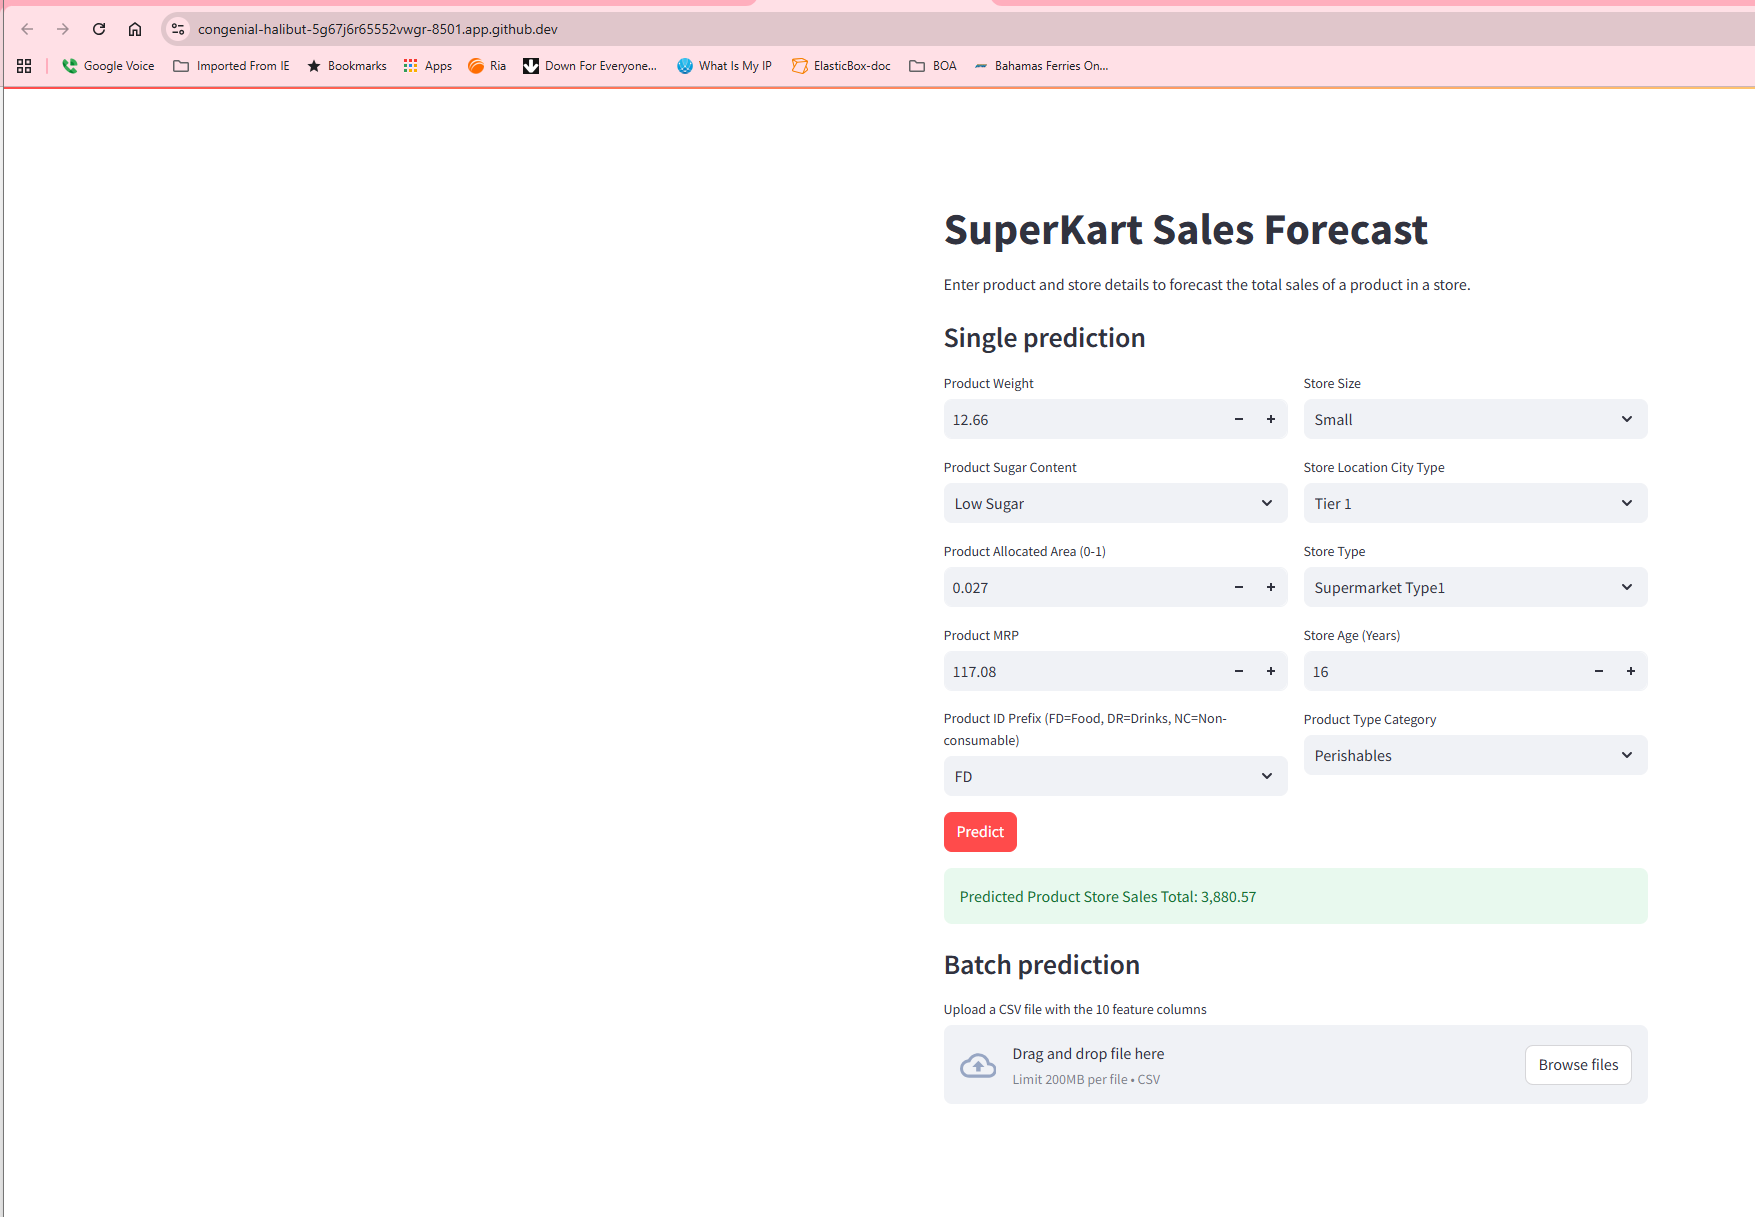

Single: "The app returned a predicted sales value of 3,880.57 for the entered product and store details."

## Batch inference - Streamlit app


2 Screenhosts below  for Batch


**Screenshot 1 - CSV uploaded and batch prediction run**

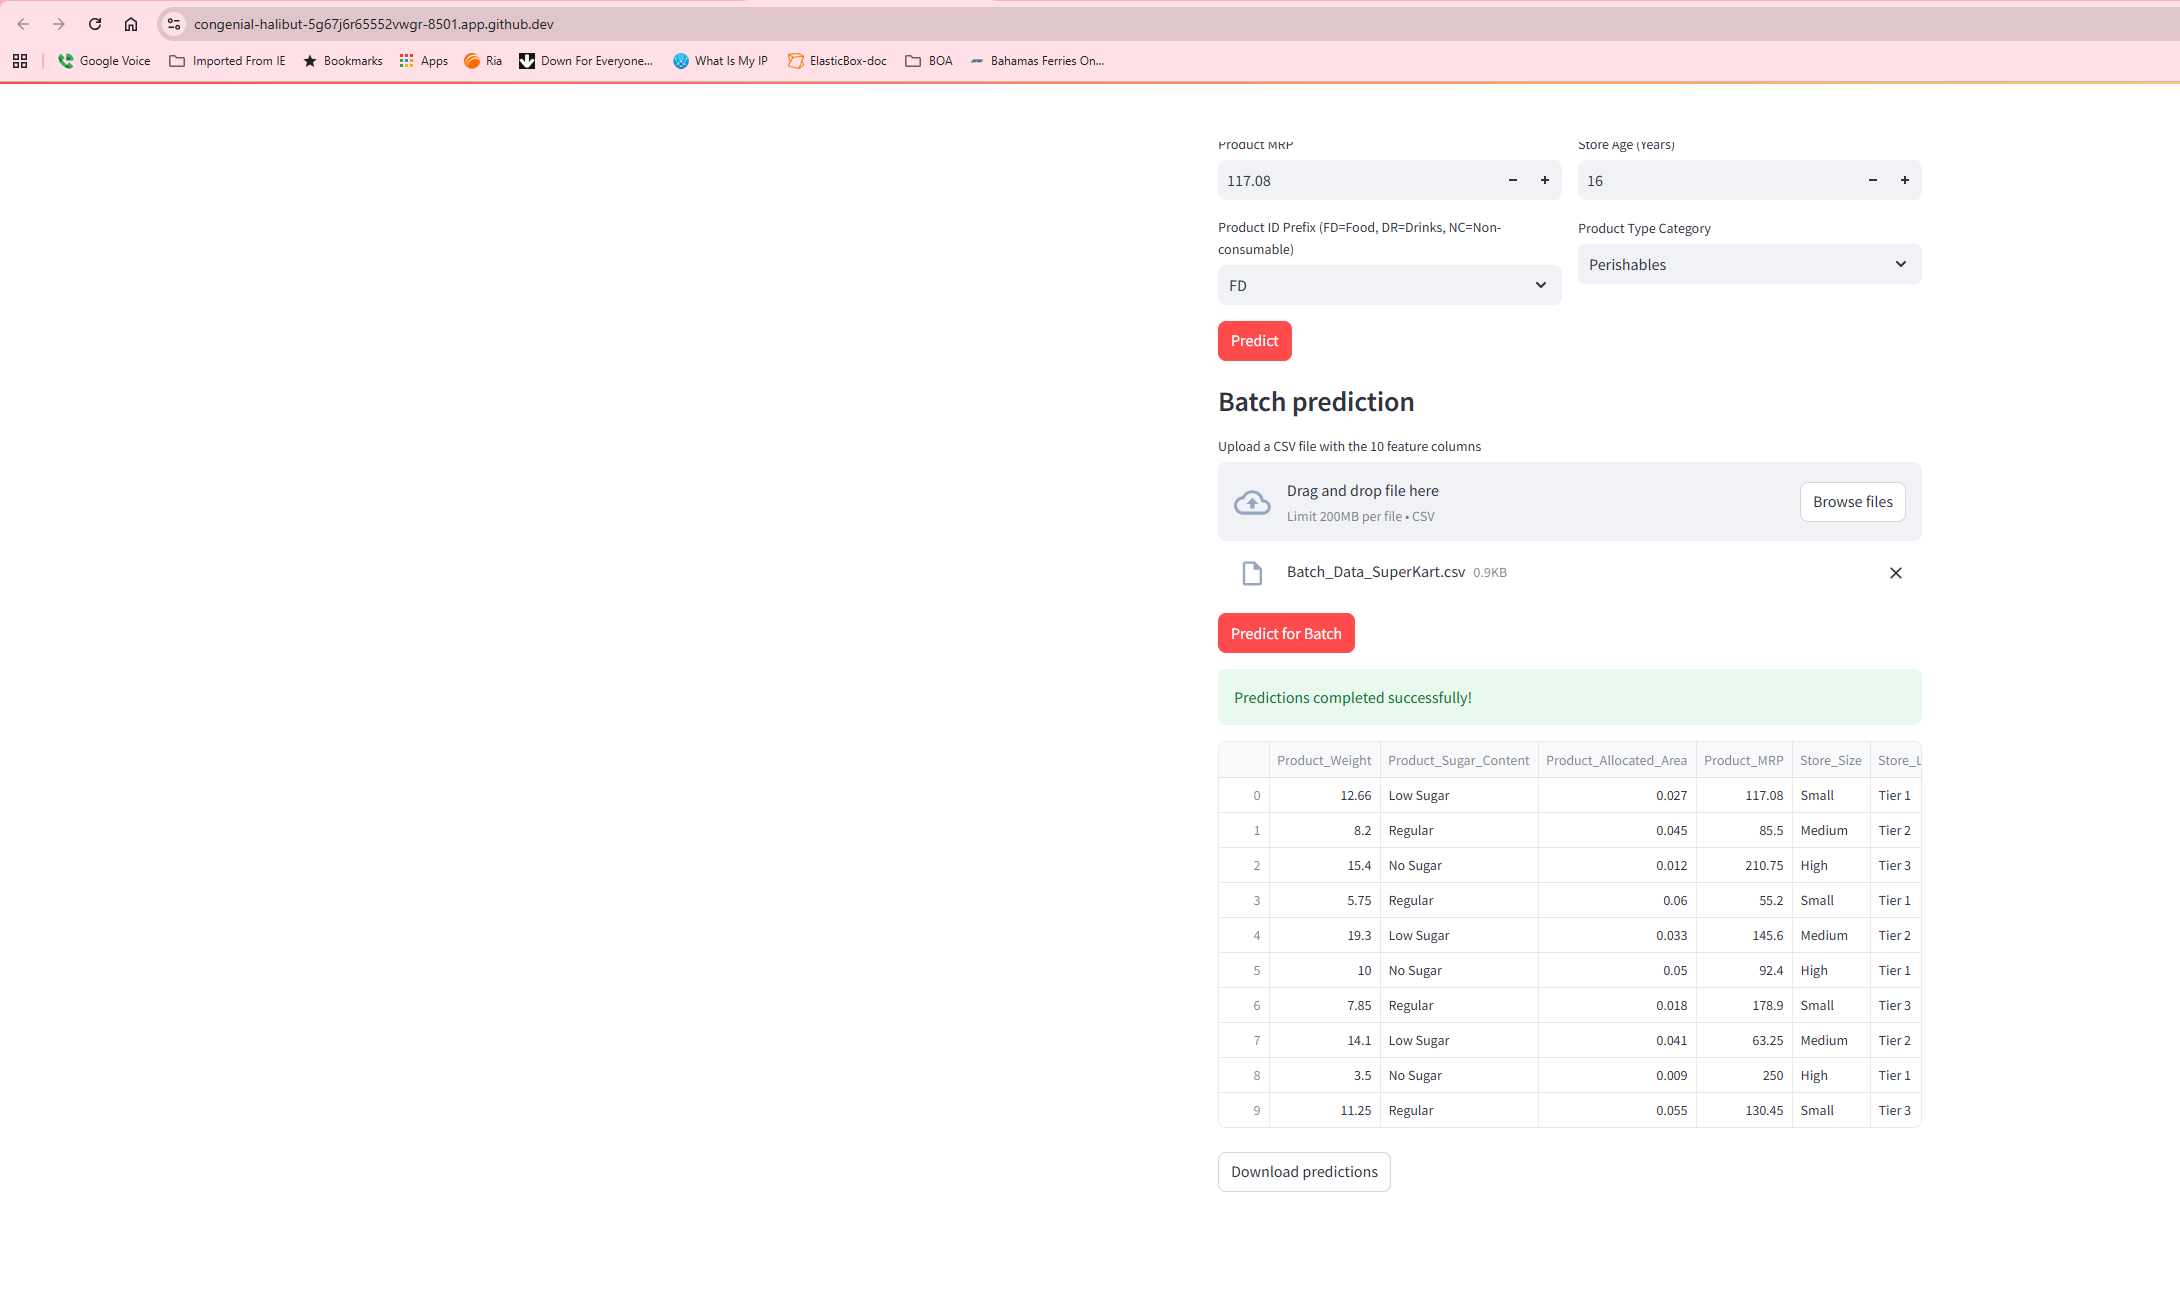

The `Batch_Data_SuperKart.csv` file (10 product-store records with the 10 model features) was uploaded through the app and sent to the Flask backend's `/v1/predictbatch` endpoint by clicking **Predict for Batch**. The app confirmed *"Predictions completed successfully!"*.

the second screenshot (the full-width table) below

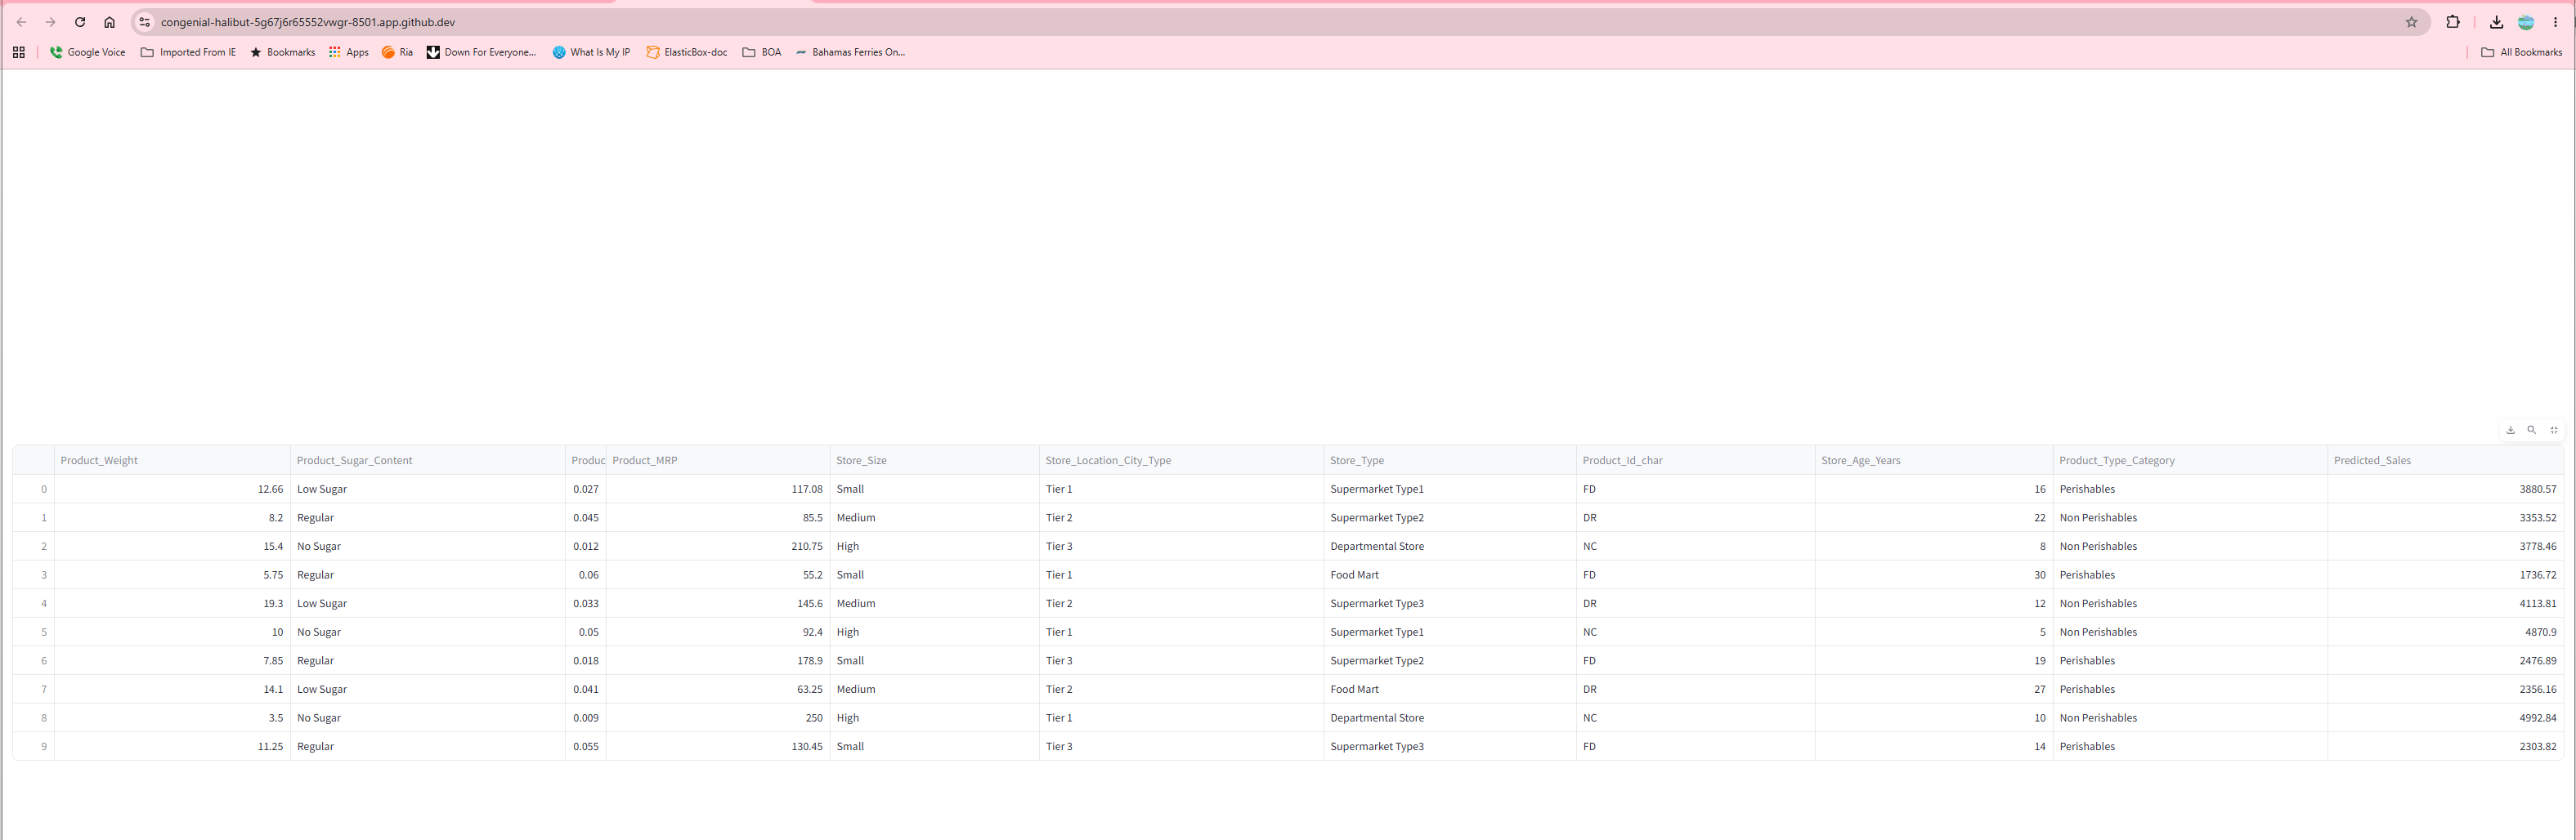

The expanded table shows every input column together with the model's **Predicted_Sales** for each row. Results can also be downloaded as a CSV with the *Download predictions* button.

Batch: "The app returned one predicted sales value for each of the 10 rows in the uploaded CSV."

# **Actionable Insights and Business Recommendations**

**Model and deployment**
- The **tuned Random Forest** explains **≈ 93% of the variation** in product-store sales on unseen data (test R² ≈ 0.926, RMSE ≈ 291, MAPE ≈ 5.2%) - accurate enough to support quarterly revenue planning and procurement.
- The model is served as a Flask REST API (online and batch endpoints) with a Streamlit front-end, each in its own Docker container, so any SuperKart system (ERP, planning sheets, BI tools) can request forecasts over HTTP.

**Insights**
- **Price (MRP) and product weight are the strongest sales drivers** (correlations 0.79 and 0.74, top model features). Higher-priced, larger-pack products generate more revenue per store.
- **Store format matters more than product type.** OUT004 (Supermarket Type2, Tier 2) earns ≈ 51% of revenue through volume; OUT003 (Departmental Store, Tier 1) earns the most per product (≈ 4,947) with premium pricing; OUT002 (Food Mart, Tier 3) earns only ≈ 7% at ≈ 1,763 per product.
- **Fruits and Vegetables and Snack Foods are the top two revenue categories in every store** (together ≈ 27% of revenue).
- **Display area does not drive sales** - allocated area has ≈ 0 correlation with sales and negligible model importance.
- Perishables bring in ≈ 35% of revenue and need faster, more accurate replenishment.

**Recommendations**
1. **Use the forecast for procurement:** run batch predictions every quarter for each store's product list and base purchase orders on them - especially for perishables (Fruits and Vegetables, Dairy, Meat) to reduce stock-outs and wastage.
2. **Replicate the OUT003 premium playbook in other Tier 1 / high-income areas:** stock higher-MRP and larger-pack products where customers can afford them.
3. **Protect and grow the volume engine (OUT004):** keep Fruits and Vegetables and Snack Foods always in stock and use the model to plan for peak demand.
4. **Review the Food Mart (OUT002) format in Tier 3 cities:** focus on value packs and the best-selling categories; evaluate whether upgrading it to a supermarket format would lift sales per product.
5. **Re-think shelf-space allocation:** since more display area does not translate into sales, reallocate space toward high-MRP, high-velocity products and test changes with A/B experiments.
6. **Keep the model healthy:** retrain each quarter on new sales data, monitor prediction error (RMSE/MAPE) against actuals, and add new features (promotions, seasonality, local competition, footfall) to improve accuracy further.

In [187]:

# Convert THIS notebook to HTML for submission.
# IMPORTANT: Save the notebook first (File -> Save, or Ctrl+S) - nbconvert reads the
# saved .ipynb file from Drive, so unsaved outputs will not appear in the HTML.
# NOTE: adjust the path/filename below to match exactly where this notebook is saved
# in your Google Drive. The quotes are required because the folder name has a space.
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/SuperKart_Full_Code_Solution_Ravikanth_Doddapaneni_V2.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/SuperKart_Full_Code_Solution_Ravikanth_Doddapaneni_V2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp] Writing 3199355 bytes to /content/drive/MyDrive/Colab Notebooks/SuperKart_Full_Code_Solution_Ravikanth_Doddapaneni_V2.html
